# TP: Predicción de Porcentaje de Grasa Corporal
## Aprendizaje de Máquina — Maestría en Inteligencia Artificial
 
**Dataset:** Body Fat Dataset  
**Observaciones:** 252  
**Variables:** 15 (Density, BodyFat, Age, Weight, Height, Neck, Chest, Abdomen, Hip, Thigh, Knee, Ankle, Biceps, Forearm, Wrist)  
**Target:** `BodyFat` — porcentaje de grasa corporal
 
---

## FASE 1: Entendimiento y Configuración

### 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
# Sklearn — módulos base
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
 
# Configuración de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
 
print('✅ Librerías importadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ Librerías importadas correctamente
   pandas  3.0.1
   numpy   2.4.2
   seaborn 0.13.2


### 2. Carga e inspección básica

In [2]:
# ⚠️ Ajustá la ruta al archivo según tu entorno
df = pd.read_csv('bodyfat.csv')
 
print(f'Shape del dataset: {df.shape}')
df.head(10)

Shape del dataset: (252, 15)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
5,1.0502,20.9,24,210.25,74.75,39.0,104.5,94.4,107.8,66.0,42.0,25.6,35.7,30.6,18.8
6,1.0549,19.2,26,181.00,69.75,36.4,105.1,90.7,100.3,58.4,38.3,22.9,31.9,27.8,17.7
7,1.0704,12.4,25,176.00,72.50,37.8,99.6,88.5,97.1,60.0,39.4,23.2,30.5,29.0,18.8
8,1.0900,4.1,25,191.00,74.00,38.1,100.9,82.5,99.9,62.9,38.3,23.8,35.9,31.1,18.2
9,1.0722,11.7,23,198.25,73.50,42.1,99.6,88.6,104.1,63.1,41.7,25.0,35.6,30.0,19.2


In [3]:
# Información de tipos y valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [4]:
# Estadísticas descriptivas completas
df.describe().round(3)

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000
mean,1.056,19.151,44.885,178.924,70.149,37.992,100.824,92.556,99.905,59.406,38.590,23.102,32.273,28.664,18.230
std,0.019,8.369,12.602,29.389,3.663,2.431,8.430,10.783,7.164,5.250,2.412,1.695,3.021,2.021,0.934
min,0.995,0.000,22.000,118.500,29.500,31.100,79.300,69.400,85.000,47.200,33.000,19.100,24.800,21.000,15.800
25%,1.041,12.475,35.750,159.000,68.250,36.400,94.350,84.575,95.500,56.000,36.975,22.000,30.200,27.300,17.600
50%,1.055,19.200,43.000,176.500,70.000,38.000,99.650,90.950,99.300,59.000,38.500,22.800,32.050,28.700,18.300
75%,1.070,25.300,54.000,197.000,72.250,39.425,105.375,99.325,103.525,62.350,39.925,24.000,34.325,30.000,18.800
max,1.109,47.500,81.000,363.150,77.750,51.200,136.200,148.100,147.700,87.300,49.100,33.900,45.000,34.900,21.400


In [5]:
# Verificación de nulos explícitos y strings ocultos
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
 
print('\n=== Verificación de tipos por columna ===')
for col in df.columns:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna().sum()
    if non_numeric > 0:
        print(f'  ⚠️  {col}: {non_numeric} valores no numéricos detectados')
    else:
        print(f'  ✅ {col}: OK')

=== Valores nulos por columna ===
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

=== Verificación de tipos por columna ===
  ✅ Density: OK
  ✅ BodyFat: OK
  ✅ Age: OK
  ✅ Weight: OK
  ✅ Height: OK
  ✅ Neck: OK
  ✅ Chest: OK
  ✅ Abdomen: OK
  ✅ Hip: OK
  ✅ Thigh: OK
  ✅ Knee: OK
  ✅ Ankle: OK
  ✅ Biceps: OK
  ✅ Forearm: OK
  ✅ Wrist: OK


---
## FASE 2: Análisis Exploratorio de Datos (EDA)
 
### 4. Detección de anomalías biológicas — BodyFat = 0.0

In [6]:
# Identificar filas con BodyFat <= 0 (biológicamente imposible)
anomalias_bodyfat = df[df['BodyFat'] <= 0]
 
print(f'Filas con BodyFat <= 0: {len(anomalias_bodyfat)}')
print()
print(anomalias_bodyfat)

Filas con BodyFat <= 0: 1

     Density  BodyFat  Age  Weight  Height  Neck  Chest  Abdomen   Hip  Thigh  \
181   1.1089      0.0   40   118.5    68.0  33.8   79.3     69.4  85.0   47.2   

     Knee  Ankle  Biceps  Forearm  Wrist  
181  33.5   20.2    27.7     24.6   16.5  


In [7]:
# DECISIÓN: Eliminar la fila con BodyFat = 0 por ser biológicamente inválida.
# Un ser humano vivo necesariamente tiene grasa corporal esencial (>2% en hombres).
# Imputar con la media podría sesgar el modelo; la eliminación es más conservadora.
 
df_clean = df[df['BodyFat'] > 0].copy()
 
print(f'Shape original : {df.shape}')
print(f'Shape limpio   : {df_clean.shape}')
print(f'Filas eliminadas: {df.shape[0] - df_clean.shape[0]}')

Shape original : (252, 15)
Shape limpio   : (251, 15)
Filas eliminadas: 1


### 5. Revisión de valores extremos — Weight y Height

In [8]:
# --- Peso máximo ---
max_weight_idx = df_clean['Weight'].idxmax()
print('=== Individuo con mayor peso (363.15 lbs ≈ 164.7 kg) ===')
print(df_clean.loc[max_weight_idx])
print()
 
# --- Altura mínima ---
min_height_idx = df_clean['Height'].idxmin()
print('=== Individuo con menor altura (29.5 pulgadas ≈ 74.9 cm) ===')
print(df_clean.loc[min_height_idx])

=== Individuo con mayor peso (363.15 lbs ≈ 164.7 kg) ===
Density      1.0202
BodyFat     35.2000
Age         46.0000
Weight     363.1500
Height      72.2500
Neck        51.2000
Chest      136.2000
Abdomen    148.1000
Hip        147.7000
Thigh       87.3000
Knee        49.1000
Ankle       29.6000
Biceps      45.0000
Forearm     29.0000
Wrist       21.4000
Name: 38, dtype: float64

=== Individuo con menor altura (29.5 pulgadas ≈ 74.9 cm) ===
Density      1.025
BodyFat     32.900
Age         44.000
Weight     205.000
Height      29.500
Neck        36.600
Chest      106.000
Abdomen    104.300
Hip        115.500
Thigh       70.600
Knee        42.500
Ankle       23.700
Biceps      33.600
Forearm     28.700
Wrist       17.400
Name: 41, dtype: float64


In [9]:
# Análisis: Height = 29.5 pulgadas es un error evidente de tipeo
# (equivale a ~75 cm, incompatible con el peso y medidas del individuo).
# La mediana del dataset es 70 pulgadas. Imputamos con la mediana.
 
mediana_height = df_clean['Height'].median()
print(f'Mediana de Height: {mediana_height} pulgadas')
 
df_clean.loc[min_height_idx, 'Height'] = mediana_height
print(f'Height corregida para índice {min_height_idx}: {df_clean.loc[min_height_idx, "Height"]}')
 
# El peso máximo (363.15 lbs) es extremo pero plausible;
# su BodyFat es consistente con las demás medidas → se conserva.
print('\n⚠️  Weight = 363.15 lbs: valor extremo pero biológicamente plausible → se conserva.')

Mediana de Height: 70.0 pulgadas
Height corregida para índice 41: 70.0

⚠️  Weight = 363.15 lbs: valor extremo pero biológicamente plausible → se conserva.


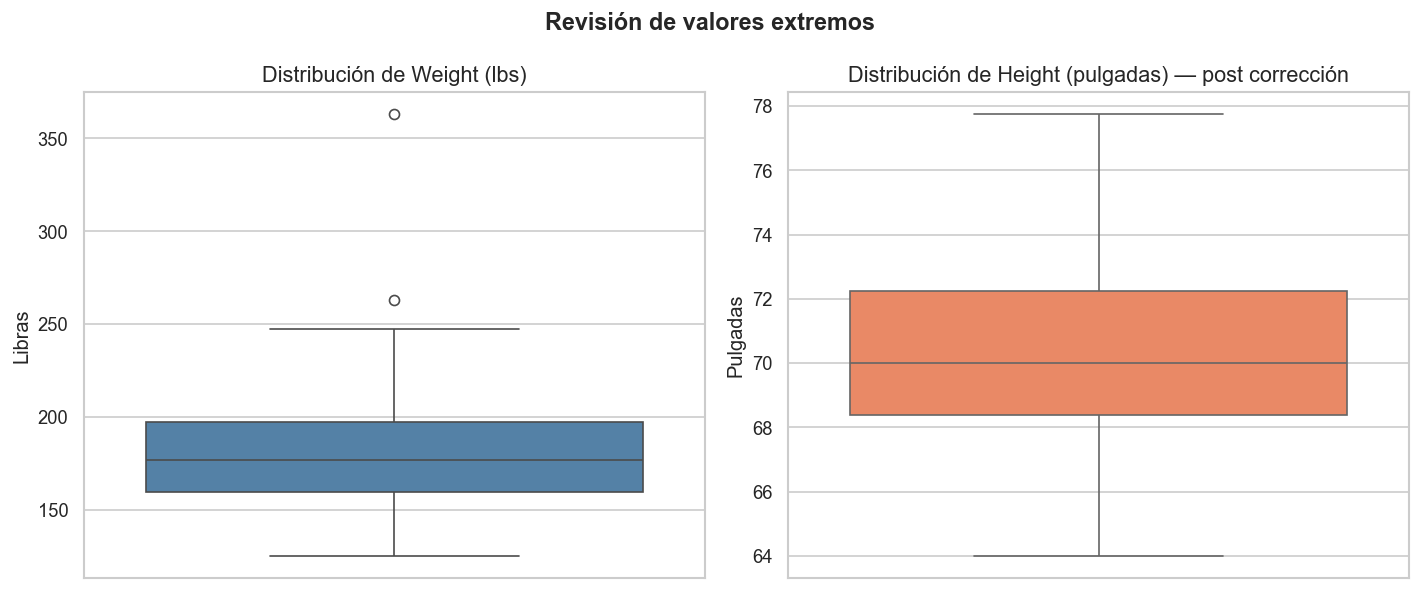

In [10]:
# Boxplots de Weight y Height para visualizar outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
sns.boxplot(y=df_clean['Weight'], ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Weight (lbs)', fontsize=13)
axes[0].set_ylabel('Libras')
 
sns.boxplot(y=df_clean['Height'], ax=axes[1], color='coral')
axes[1].set_title('Distribución de Height (pulgadas) — post corrección', fontsize=13)
axes[1].set_ylabel('Pulgadas')
 
plt.suptitle('Revisión de valores extremos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Distribución del Target — BodyFat

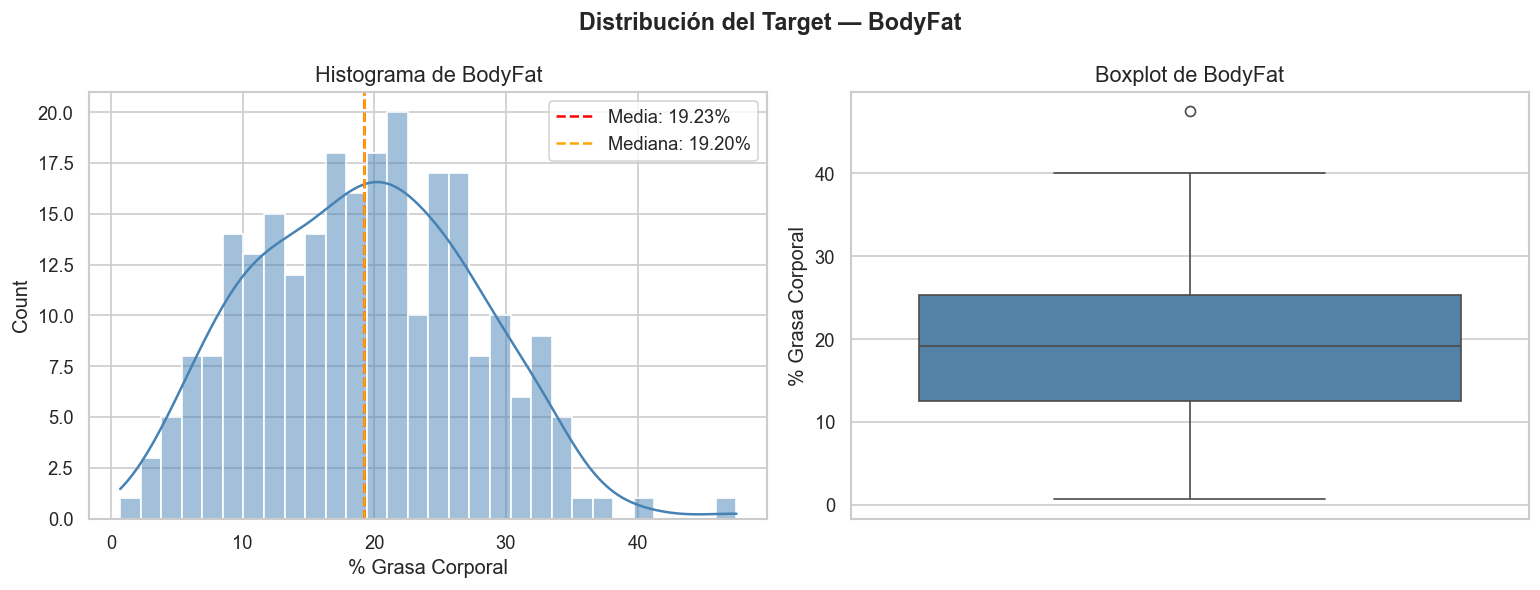

Asimetría (skewness): 0.1725  → leve sesgo positivo
Curtosis (kurtosis) : -0.3513


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Histograma con KDE
sns.histplot(df_clean['BodyFat'], bins=30, kde=True, color='steelblue',
             edgecolor='white', ax=axes[0])
axes[0].axvline(df_clean['BodyFat'].mean(), color='red', linestyle='--',
                label=f'Media: {df_clean["BodyFat"].mean():.2f}%')
axes[0].axvline(df_clean['BodyFat'].median(), color='orange', linestyle='--',
                label=f'Mediana: {df_clean["BodyFat"].median():.2f}%')
axes[0].set_title('Histograma de BodyFat', fontsize=13)
axes[0].set_xlabel('% Grasa Corporal')
axes[0].legend()
 
# Boxplot
sns.boxplot(y=df_clean['BodyFat'], color='steelblue', ax=axes[1])
axes[1].set_title('Boxplot de BodyFat', fontsize=13)
axes[1].set_ylabel('% Grasa Corporal')
 
plt.suptitle('Distribución del Target — BodyFat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Estadísticas de asimetría
skewness = df_clean['BodyFat'].skew()
kurtosis = df_clean['BodyFat'].kurt()
print(f'Asimetría (skewness): {skewness:.4f}  → {"leve sesgo positivo" if skewness > 0 else "leve sesgo negativo"}')
print(f'Curtosis (kurtosis) : {kurtosis:.4f}')

### 7. Matriz de Correlación — Heatmap

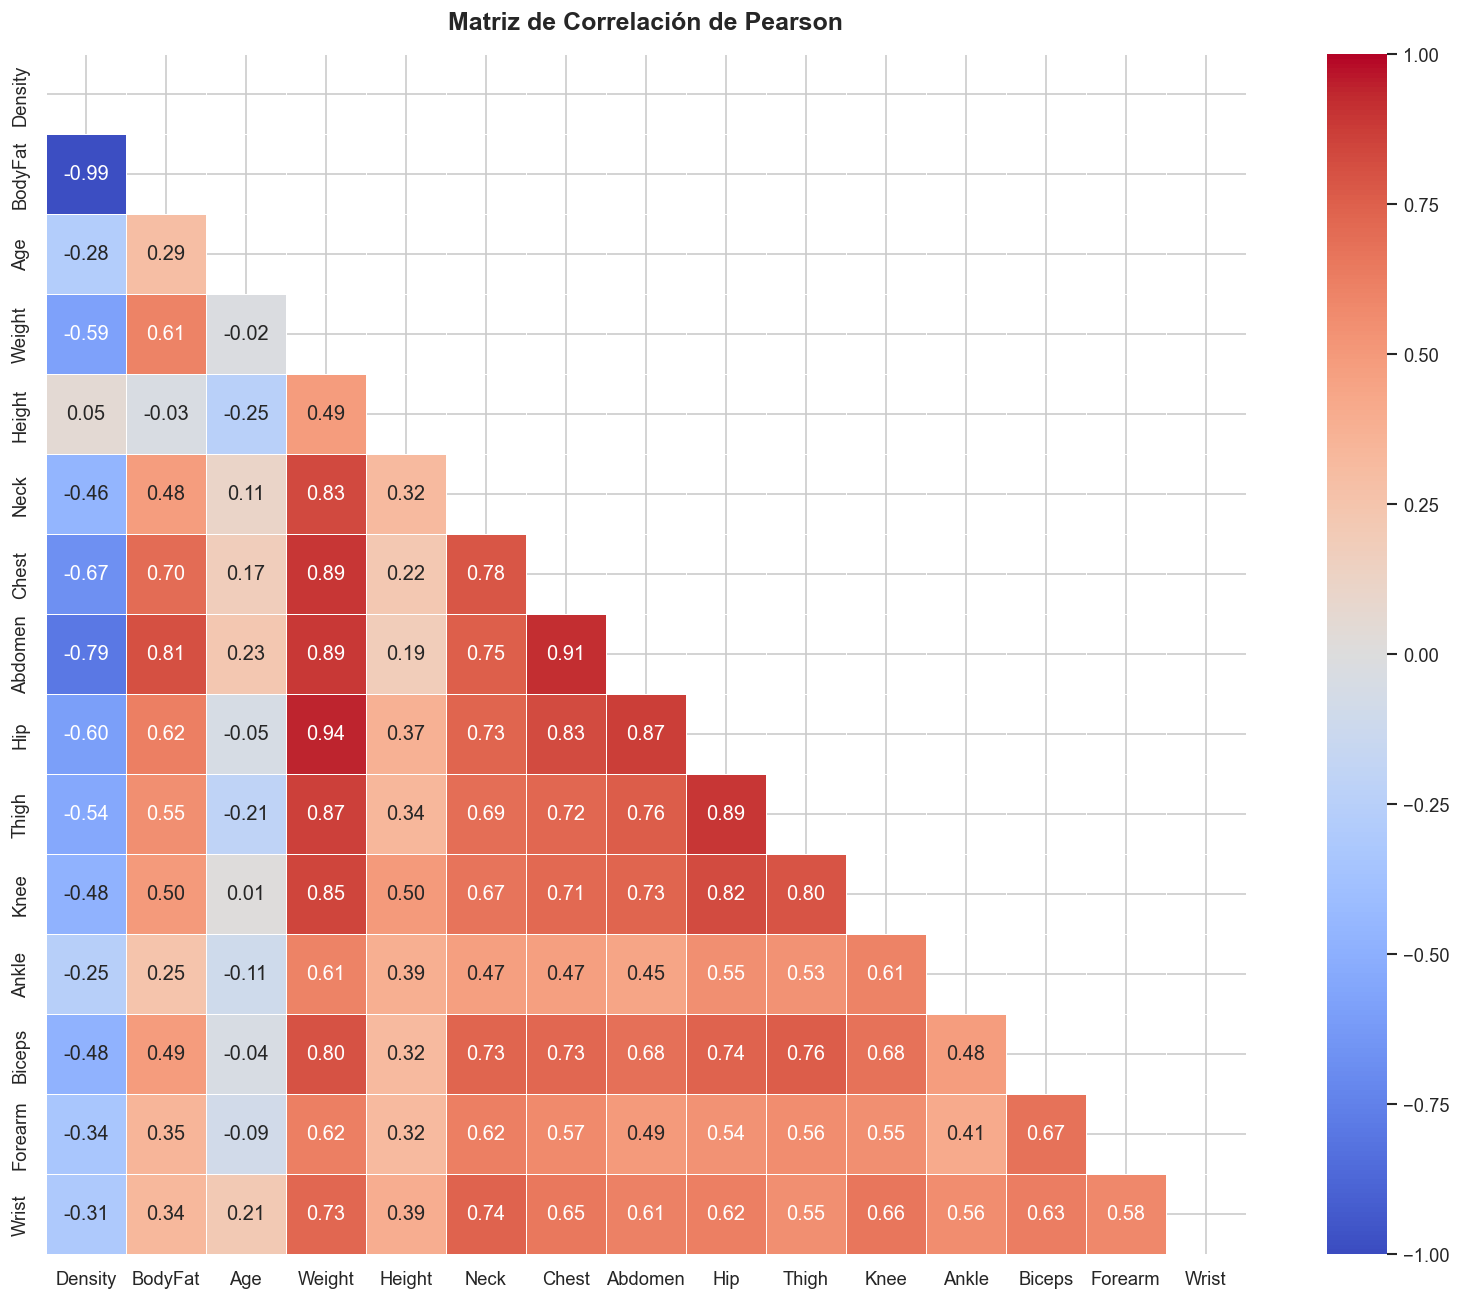

In [12]:
# Calculamos la matriz de correlación de Pearson
corr_matrix = df_clean.corr(numeric_only=True)
 
fig, ax = plt.subplots(figsize=(14, 11))
 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
 
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)
 
ax.set_title('Matriz de Correlación de Pearson', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

=== Correlación con BodyFat (descendente) ===
Abdomen    0.809725
Chest      0.695607
Hip        0.617980
Weight     0.605048
Thigh      0.550033
Knee       0.499019
Biceps     0.486752
Neck       0.482739
Forearm    0.349466
Wrist      0.335434
Age        0.291061
Ankle      0.254455
Height    -0.032532
Density   -0.988010


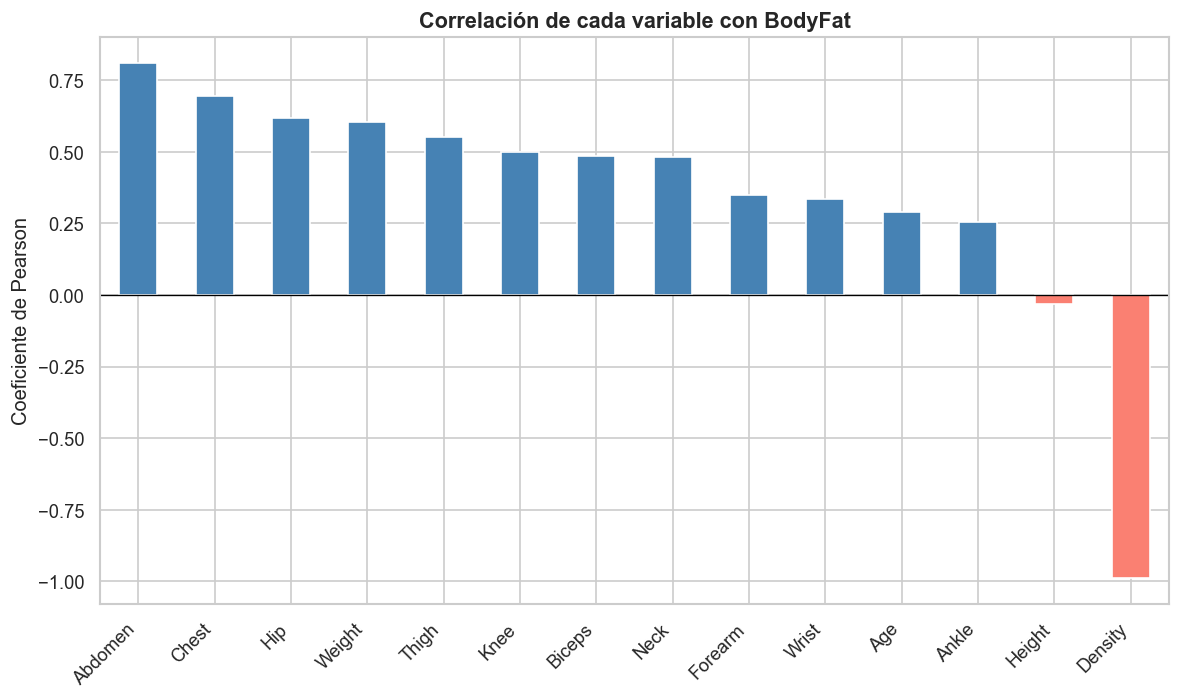

In [13]:
# Correlación de cada variable con BodyFat — ordenada
corr_target = corr_matrix['BodyFat'].drop('BodyFat').sort_values(ascending=False)
 
print('=== Correlación con BodyFat (descendente) ===')
print(corr_target.to_string())
 
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in corr_target.values]
corr_target.plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable con BodyFat', fontsize=13, fontweight='bold')
ax.set_ylabel('Coeficiente de Pearson')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# Identificar pares de predictores con alta multicolinealidad (|r| > 0.85)
print('=== Pares con alta multicolinealidad (|r| > 0.85, excl. Density) ===')
predictores = [c for c in df_clean.columns if c not in ['BodyFat', 'Density']]
corr_pred = df_clean[predictores].corr()
 
pares_altos = []
for i in range(len(predictores)):
    for j in range(i+1, len(predictores)):
        r = corr_pred.iloc[i, j]
        if abs(r) > 0.85:
            pares_altos.append((predictores[i], predictores[j], round(r, 3)))
 
pares_df = pd.DataFrame(pares_altos, columns=['Variable 1', 'Variable 2', 'r'])
pares_df = pares_df.sort_values('r', ascending=False)
print(pares_df.to_string(index=False))

=== Pares con alta multicolinealidad (|r| > 0.85, excl. Density) ===
Variable 1 Variable 2     r
    Weight        Hip 0.940
     Chest    Abdomen 0.914
       Hip      Thigh 0.894
    Weight      Chest 0.892
    Weight    Abdomen 0.886
   Abdomen        Hip 0.872
    Weight      Thigh 0.866
    Weight       Knee 0.851


### 8. Análisis Bivariado — Scatter plots vs BodyFat

Top 6 predictores: ['Abdomen', 'Chest', 'Hip', 'Weight', 'Thigh', 'Knee']


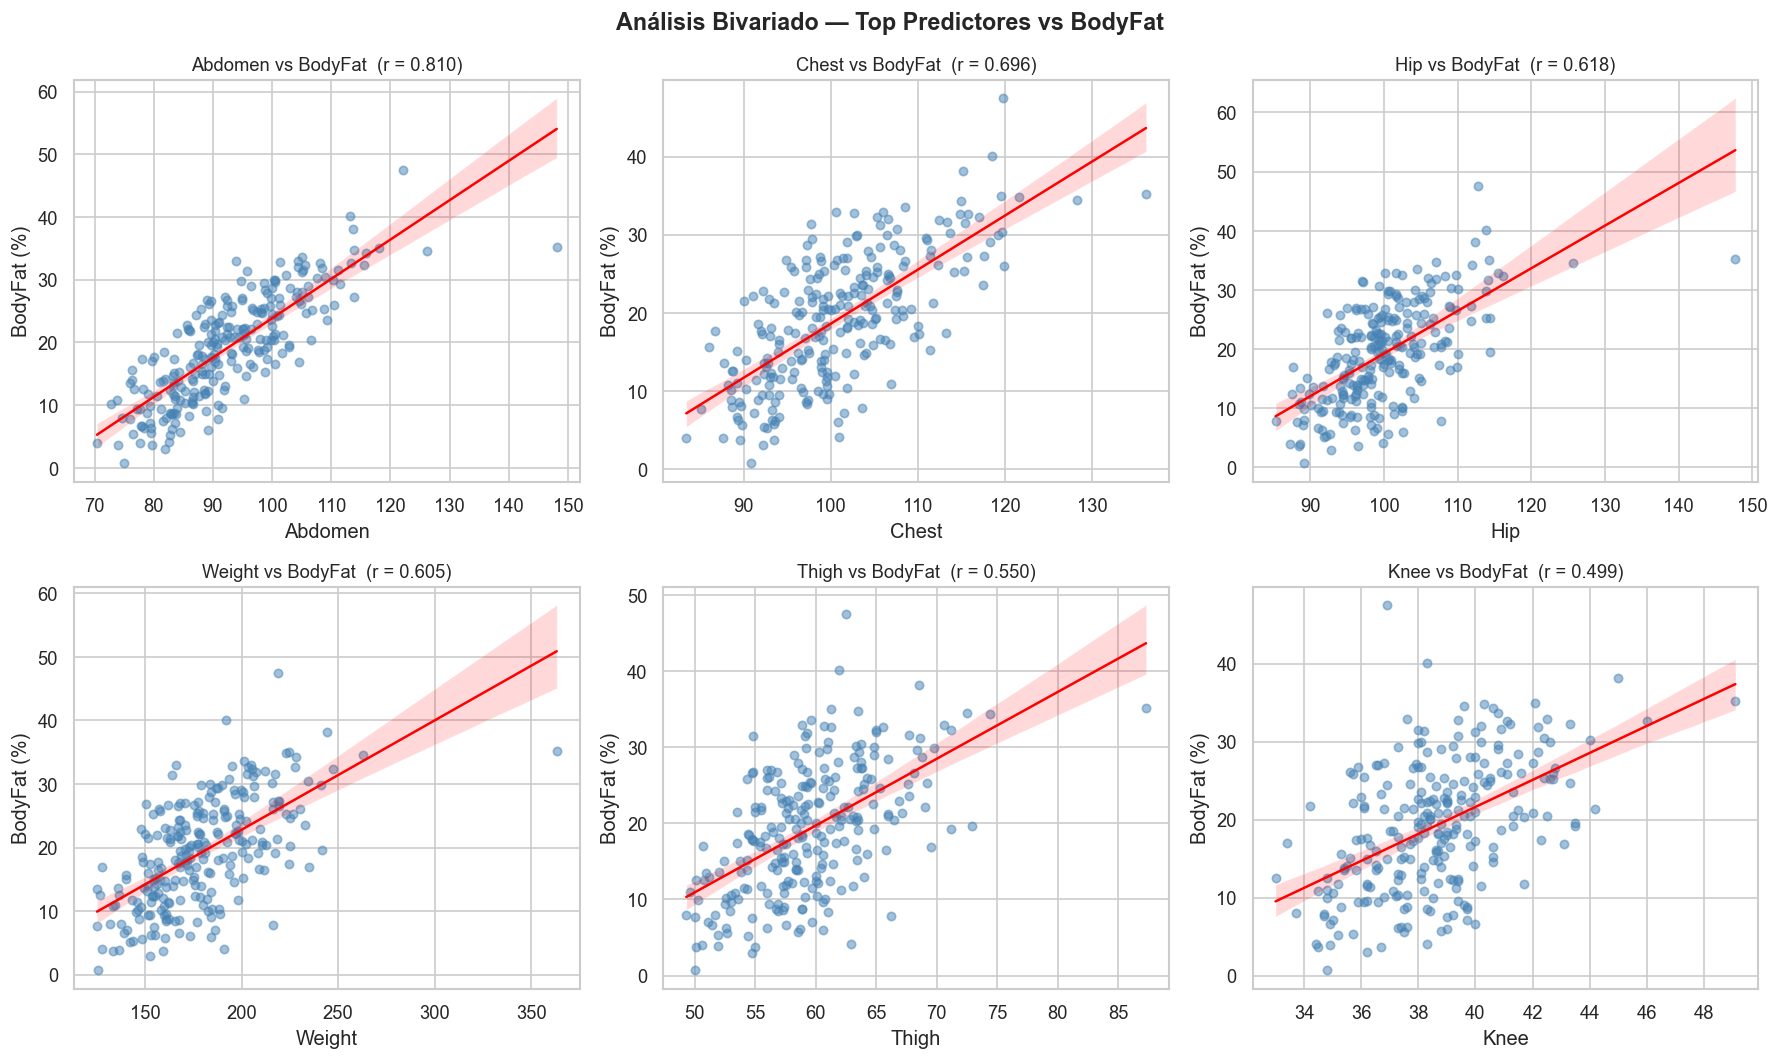

In [15]:
# Top 6 predictores más correlacionados con BodyFat (excluyendo Density)
top_vars = corr_target.drop('Density', errors='ignore').abs().sort_values(ascending=False).head(6).index.tolist()
print(f'Top 6 predictores: {top_vars}')
 
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
 
for i, var in enumerate(top_vars):
    r = corr_matrix.loc[var, 'BodyFat']
    sns.regplot(
        data=df_clean,
        x=var,
        y='BodyFat',
        ax=axes[i],
        scatter_kws={'alpha': 0.5, 's': 25, 'color': 'steelblue'},
        line_kws={'color': 'red', 'linewidth': 1.5}
    )
    axes[i].set_title(f'{var} vs BodyFat  (r = {r:.3f})', fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('BodyFat (%)')
 
plt.suptitle('Análisis Bivariado — Top Predictores vs BodyFat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

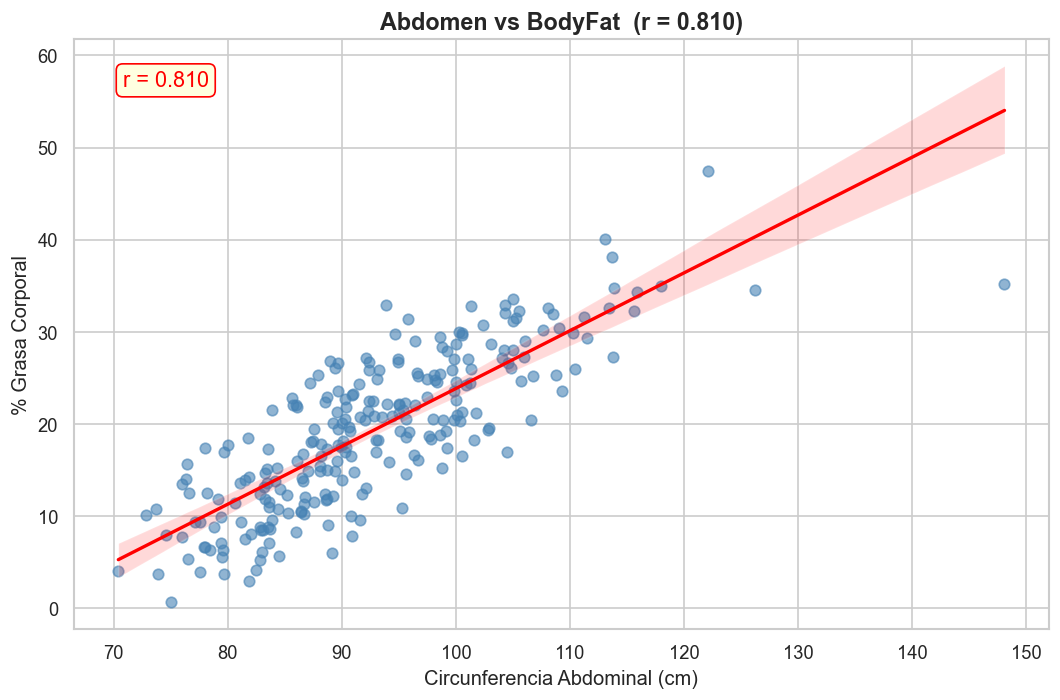

In [16]:
# Scatter plot destacado: Abdomen vs BodyFat (predictor más fuerte)
fig, ax = plt.subplots(figsize=(9, 6))
 
r_abd = corr_matrix.loc['Abdomen', 'BodyFat']
 
sns.regplot(
    data=df_clean, x='Abdomen', y='BodyFat',
    scatter_kws={'alpha': 0.6, 's': 40, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)
 
ax.set_title(f'Abdomen vs BodyFat  (r = {r_abd:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Circunferencia Abdominal (cm)', fontsize=12)
ax.set_ylabel('% Grasa Corporal', fontsize=12)
ax.annotate(f'r = {r_abd:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=13, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red'))
 
plt.tight_layout()
plt.show()

---
## Resumen del EDA
 
| Hallazgo | Detalle | Acción tomada |
|---|---|---|
| BodyFat = 0.0 | Biológicamente imposible | Fila eliminada |
| Height = 29.5 pulgadas | Error de tipeo evidente (~75 cm) | Imputado con mediana (70") |
| Weight = 363.15 lbs | Extremo pero plausible | Conservado |
| Multicolinealidad alta | Chest, Abdomen, Hip, Weight muy correlacionados entre sí | A considerar en modelado (PCA, Ridge, Lasso) |
| Predictor más fuerte | Abdomen (r ≈ 0.81 con BodyFat) | Priorizar en modelos lineales |
| Distribución BodyFat | Leve sesgo positivo, outliers en valores altos | Posible transformación log si es necesario |
 
**Próximos pasos pensados:**
 
Antes de pasar a la próxima Fase sacar Density por dataleakeage.
 
### Fase 3: Preprocesamiento de Datos
 
9. *Data Splitting:* Usa train_test_split para separar en conjuntos de entrenamiento y prueba (**70/30**). Fija el random_state para asegurar la reproducibilidad de tus resultados.
10. *Tratamiento de Outliers:* Aplica la decisión tomada en los pasos 4 y 5.
11. *Separación de variables:* Divide tu dataset en la matriz de características X (excluyendo BodyFat y Density) y tu vector objetivo y (BodyFat).
12. *Escalado de features:* Aplica StandardScaler. Regla de oro: Fit solo en train, transform en train y test.
 
### Fase 4: Modelado — Algoritmos Lineales
 
13. *Métricas de Evaluación:* Define tus KPIs: RMSE, MAE y R².
14. *Modelo Baseline:* DummyRegressor que predice la media del set de entrenamiento.
15. *Modelo Regularizado (Lasso):* Búsqueda de hiperparámetros **exclusivamente sobre train** mediante Cross-Validation.
 
### Fase 5: Algoritmos No Lineales y Ensambles
 
16. *Support Vector Regressor (SVR):* kernel lineal y RBF, optimizados con CV sobre train.
17. *Random Forest:* RandomForestRegressor, optimizado con CV sobre train.
18. *Gradient Boosting:* HistGradientBoostingRegressor, optimizado con CV sobre train.
 
### Fase 6: Optimización y Validación Robusta
 
19. *Validación Cruzada (K-Fold):* Comparación robusta de todos los modelos sobre train.
20. *Evaluación Final:* Mejores modelos evaluados contra el set de Test intacto.
21. *Análisis de Errores e Importancia:* Residuos, coeficientes e importancia de features.

---
## FASE 3: Preprocesamiento de Datos
 
### 9. Separación entre la variable objetivo (y) y las features explicativas (X) + Data Splitting — Train / Test (70 / 30)
 
Antes de dividir el dataset eliminamos la variable `Density`.  
Esto es fundamental para evitar **data leakage**: `Density` se obtiene sumergiéndose en agua y es precisamente el insumo con el que se calcula `BodyFat` mediante la ecuación de Siri (1956). Incluirla como predictor significaría que el modelo "conoce la respuesta" antes de predecir, haciendo la evaluación completamente inválida.
 
> **Cambio respecto a la versión anterior:** Se adopta un split **70/30** en lugar de 80/20.  
> Con n=251 observaciones, este ajuste otorga 75 muestras al set de test, lo que mejora la  
> estabilidad de las métricas de evaluación final sin sacrificar capacidad de entrenamiento.

In [17]:
# ── Eliminación de Density por data leakage ────────────────────────────────────
# Density es la variable con la que se CALCULA BodyFat (ecuación de Siri).
# Mantenerla como predictor invalidaría por completo la evaluación del modelo.
 
df_model = df_clean.drop(columns=['Density'])
 
print(f'Variables disponibles tras eliminar Density: {df_model.shape[1]}')
print(f'Columnas: {df_model.columns.tolist()}')
 
# ── Train / Test split 70 / 30 ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
 
X = df_model.drop(columns=['BodyFat'])
y = df_model['BodyFat']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,       # ← 30% para test (antes era 0.20)
    random_state=42       # reproducibilidad garantizada
)
 
print(f'\nTamaños del split:')
print(f'  X_train : {X_train.shape}   ({X_train.shape[0] / len(X) * 100:.0f}%)')
print(f'  X_test  : {X_test.shape}    ({X_test.shape[0]  / len(X) * 100:.0f}%)')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')

Variables disponibles tras eliminar Density: 14
Columnas: ['BodyFat', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']

Tamaños del split:
  X_train : (175, 13)   (70%)
  X_test  : (76, 13)    (30%)
  y_train : (175,)
  y_test  : (76,)


### 10. Tratamiento de Outliers en el set de entrenamiento
 
En el paso 5 identificamos un individuo con **Height = 29.5 pulgadas** (~75 cm).  
En ese momento se optó por imputar con la mediana asumiendo un posible error de tipeo.  
Sin embargo, revisando el perfil completo de ese individuo, sus medidas corporales (peso, circunferencias) son consistentes con una persona adulta de baja estatura real, lo que apunta a que se trata de una persona con **enanismo** y no a un error de carga.
 
> **¿Por qué eliminarlo?**  
> El enanismo afecta a **menos del 0.01%** de la población mundial  
> (≈ 651.700 personas sobre ~8.000 millones; fuente: *welly.it.com / LPA*).  
> La forma más frecuente, la acondroplasia, ocurre en aproximadamente **1 de cada 25.000 personas**.  
> Dado que el dataset representa a la población general adulta masculina y la condición  
> es extremadamente infrecuente, incluir este individuo sesgaría las relaciones  
> peso-altura y circunferencias-grasa sin que el modelo vaya a generalizar sobre  
> esa subpoblación. La decisión conservadora es **retirarlo únicamente del set de entrenamiento**,  
> preservando la integridad del set de test.

In [18]:
# ── Identificar el individuo con menor Height en el set de entrenamiento ───────
min_height_train_idx = X_train['Height'].idxmin()
 
print('=== Individuo con menor altura en el set de entrenamiento ===')
print(X_train.loc[min_height_train_idx])
print(f'\n  BodyFat : {y_train.loc[min_height_train_idx]:.2f} %')
print(f'  Height  : {X_train.loc[min_height_train_idx, "Height"]:.1f} pulgadas')
 
# Identificamos el índice original del individuo con 29.5 pulgadas
df_raw = pd.read_csv('bodyfat.csv')
df_raw_clean = df_raw[df_raw['BodyFat'] > 0].copy()
outlier_original_idx = df_raw_clean['Height'].idxmin()
 
print(f'\nÍndice del individuo con enanismo (Height=29.5"): {outlier_original_idx}')
print(f'¿Está en X_train? {outlier_original_idx in X_train.index}')
print(f'¿Está en X_test?  {outlier_original_idx in X_test.index}')

=== Individuo con menor altura en el set de entrenamiento ===
Age         51.0
Weight     219.0
Height      64.0
Neck        41.2
Chest      119.8
Abdomen    122.1
Hip        112.8
Thigh       62.5
Knee        36.9
Ankle       23.6
Biceps      34.7
Forearm     29.1
Wrist       18.4
Name: 215, dtype: float64

  BodyFat : 47.50 %
  Height  : 64.0 pulgadas

Índice del individuo con enanismo (Height=29.5"): 41
¿Está en X_train? True
¿Está en X_test?  False


In [19]:
# ── Eliminación del outlier de enanismo del set de entrenamiento ───────────────
# Solo se elimina si cayó en train; si cayó en test, se conserva intacto.
 
if outlier_original_idx in X_train.index:
    X_train = X_train.drop(index=outlier_original_idx)
    y_train = y_train.drop(index=outlier_original_idx)
    print(f'✅ Individuo (idx={outlier_original_idx}) eliminado del set de entrenamiento.')
    print(f'   Nuevo tamaño de X_train: {X_train.shape}')
else:
    print(f'⚠️  El individuo cayó en el set de TEST. No se elimina (set de test intacto).')
    print(f'   Tamaño de X_train sin cambios: {X_train.shape}')

✅ Individuo (idx=41) eliminado del set de entrenamiento.
   Nuevo tamaño de X_train: (174, 13)


### 12. Escalado de features — StandardScaler
 
Las variables del dataset conviven en escalas muy distintas: peso en libras (~100-300),  
circunferencias en cm (~70-130), edad en años (~20-80).  
Esta disparidad afecta negativamente a algoritmos basados en distancias o regularización  
(SVR, Lasso, Ridge), que penalizan en función de la magnitud de los coeficientes.
 
**Regla de oro**: `fit` **solo** sobre el set de entrenamiento → `transform` sobre train y test.  
Hacer `fit` sobre todo el dataset constituiría **data leakage** (el scaler "vería" el futuro).

In [20]:
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()
 
# Fit SOLO en train — el scaler aprende μ y σ únicamente del entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
 
# Transform en test — se aplica la misma μ y σ aprendidas en train
X_test_scaled  = scaler.transform(X_test)
 
# Convertimos a DataFrame para mantener los nombres de columnas (útil en pasos posteriores)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)
 
print('=== Verificación del escalado (X_train_scaled) ===')
print(X_train_scaled.describe().round(3).loc[['mean', 'std']].T)

=== Verificación del escalado (X_train_scaled) ===
         mean    std
Age       0.0  1.003
Weight   -0.0  1.003
Height   -0.0  1.003
Neck     -0.0  1.003
Chest    -0.0  1.003
Abdomen  -0.0  1.003
Hip       0.0  1.003
Thigh     0.0  1.003
Knee     -0.0  1.003
Ankle     0.0  1.003
Biceps    0.0  1.003
Forearm   0.0  1.003
Wrist    -0.0  1.003


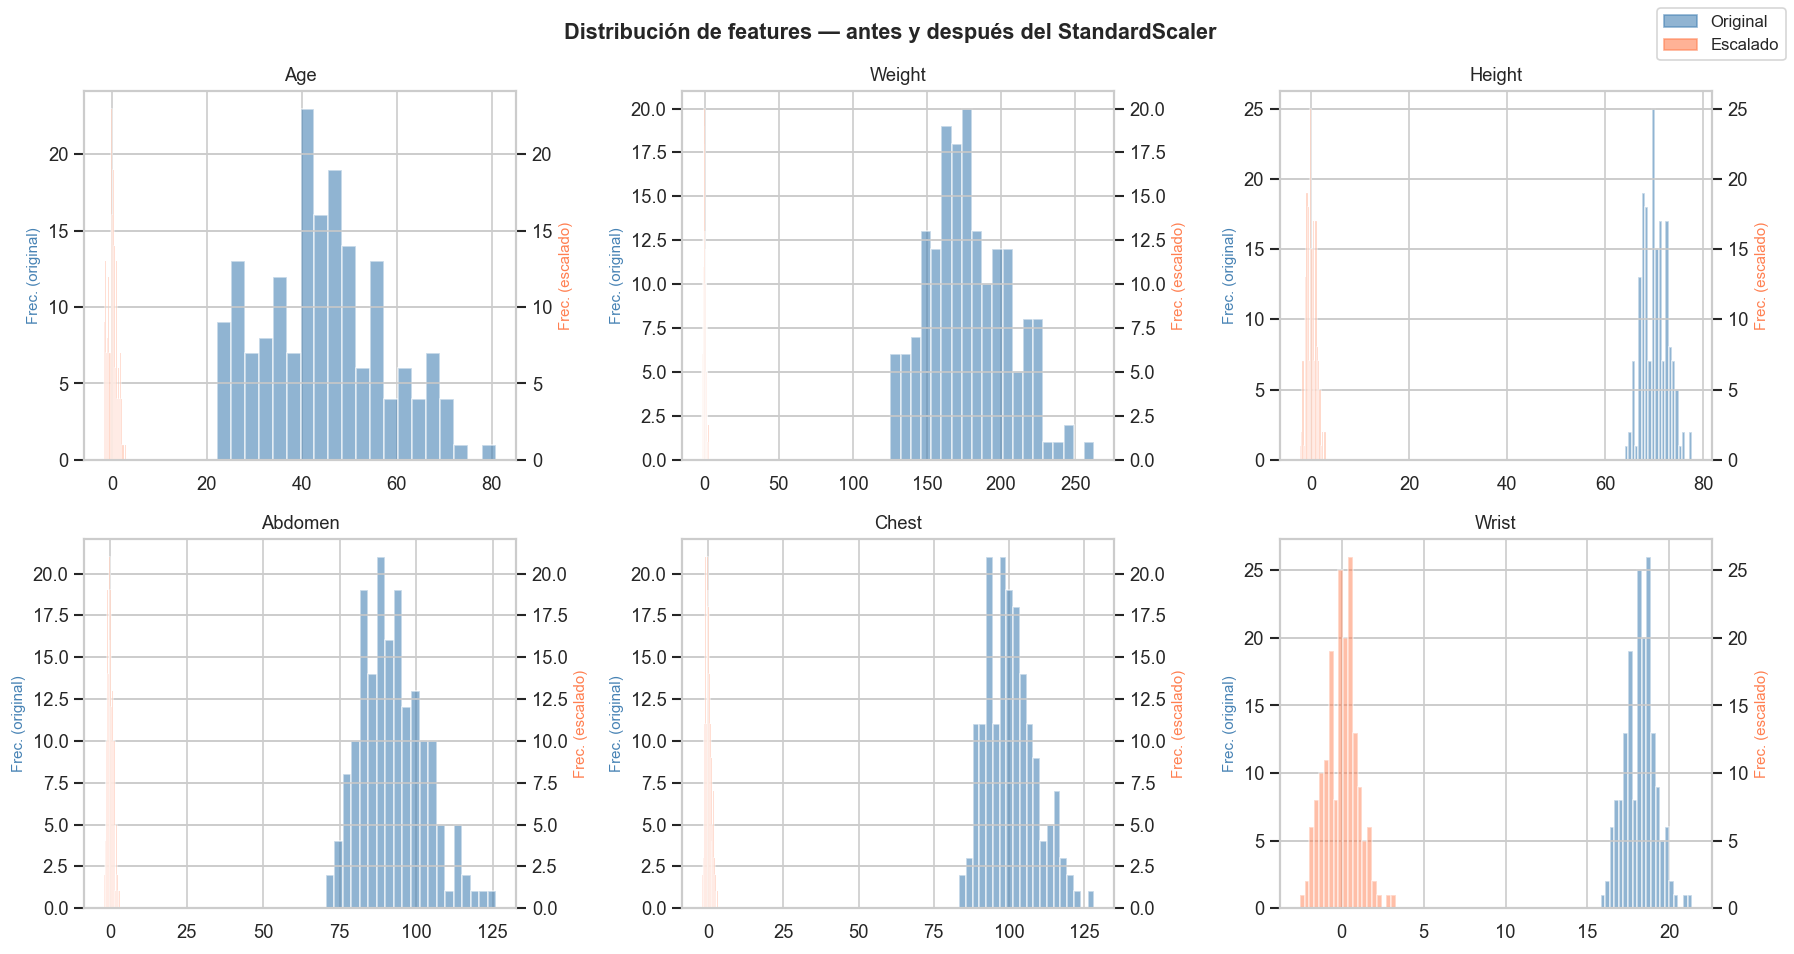

✅ Fase 3 completada. Datos listos para modelado.


In [21]:
# Visualización: distribución de algunas features antes y después del escalado
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
 
features_check = ['Age', 'Weight', 'Height', 'Abdomen', 'Chest', 'Wrist']
 
for i, feat in enumerate(features_check):
    ax = axes[i // 3][i % 3]
    ax.hist(X_train[feat], bins=20, alpha=0.6, color='steelblue', label='Original', edgecolor='white')
    ax2 = ax.twinx()
    ax2.hist(X_train_scaled[feat], bins=20, alpha=0.5, color='coral', label='Escalado', edgecolor='white')
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel('Frec. (original)', color='steelblue', fontsize=9)
    ax2.set_ylabel('Frec. (escalado)', color='coral', fontsize=9)
 
handles = [
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.6),
    plt.Rectangle((0,0),1,1, color='coral',     alpha=0.6)
]
fig.legend(handles, ['Original', 'Escalado'], loc='upper right', fontsize=10)
plt.suptitle('Distribución de features — antes y después del StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
print('✅ Fase 3 completada. Datos listos para modelado.')

---
## FASE 4: Modelado — Algoritmos Lineales
 
### 13. Métricas de evaluación
 
Para este problema de **regresión** usaremos tres métricas complementarias:
 
| Métrica | Fórmula | Qué mide | Unidad |
|---|---|---|---|
| **RMSE** | √MSE | Error promedio penalizando errores grandes | % grasa corporal |
| **MAE** | (1/n)·Σ\|y−ŷ\| | Error absoluto promedio, más robusto a outliers | % grasa corporal |
| **R²** | 1 − SS_res/SS_tot | Proporción de varianza explicada por el modelo | adimensional [0, 1] |
 
> **¿Por qué las tres?**  
> RMSE da mayor peso a errores grandes (útil para detectar predicciones muy alejadas).  
> MAE es más interpretable en la unidad original.  
> R² permite comparar directamente modelos independientemente de la escala del target.  
> Usarlas en conjunto ofrece una imagen completa del desempeño.

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
 
def evaluar_modelo(nombre, y_real, y_pred):
    """Calcula e imprime RMSE, MAE y R² para un modelo dado."""
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f'  {nombre:<40}  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}  |  R²: {r2:.4f}')
    return {'Modelo': nombre, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R²': round(r2, 4)}
 
print('✅ Función de evaluación definida.')
resultados = []   # lista donde acumularemos los resultados de todos los modelos

✅ Función de evaluación definida.


### 14. Modelo Baseline — DummyRegressor
 
Antes de entrenar cualquier modelo de Machine Learning necesitamos un **piso de referencia**:  
¿cuánto error cometería alguien que, sin mirar las variables, siempre predice la media del set de entrenamiento?  
Todo modelo real *debe* superar este umbral para justificar su complejidad.

In [23]:
from sklearn.dummy import DummyRegressor
 
# El DummyRegressor con strategy='mean' predice siempre la media del y_train
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train)
 
y_pred_dummy_train = dummy.predict(X_train_scaled)
y_pred_dummy_test  = dummy.predict(X_test_scaled)
 
print('=== Baseline — DummyRegressor (predice siempre la media) ===')
print(f' Media de y_train utilizada: {dummy.constant_.item():.4f} %')
print()
print('Train:')
res_dummy_train = evaluar_modelo('Dummy (train)', y_train, y_pred_dummy_train)
print('Test:')
res_dummy_test  = evaluar_modelo('Dummy (test)',  y_test,  y_pred_dummy_test)
resultados.append(res_dummy_test)
 
print()
print('⚠️  Un R² = 0.0 en test confirma que el baseline no explica varianza alguna.')
print('    Todo modelo ML deberá superar estos valores.')

=== Baseline — DummyRegressor (predice siempre la media) ===
 Media de y_train utilizada: 19.2483 %

Train:
  Dummy (train)                             RMSE: 8.8400  |  MAE: 7.3018  |  R²: 0.0000
Test:
  Dummy (test)                              RMSE: 6.7151  |  MAE: 5.5959  |  R²: -0.0014

⚠️  Un R² = 0.0 en test confirma que el baseline no explica varianza alguna.
    Todo modelo ML deberá superar estos valores.


### 15. Modelo Regularizado — Regresión Lasso con búsqueda de hiperparámetros por Cross-Validation
 
**¿Por qué Lasso y no Ridge?**  
- Ridge (penalización L2) reduce los coeficientes pero nunca los lleva exactamente a cero.  
- Lasso (penalización L1) **fuerza a cero** los coeficientes de los predictores menos relevantes,  
  actuando como selector automático de features. Dado que tenemos multicolinealidad alta  
  (visto en la Fase 2) y queremos un modelo interpretable, Lasso es la elección natural.
 
**Principio clave — el test set es intocable hasta la evaluación final:**  
La búsqueda del mejor `alpha` se realiza **exclusivamente sobre el set de entrenamiento**  
usando `LassoCV` con k-fold cross-validation interno.  
Esto garantiza que el set de test sea un estimador completamente independiente del rendimiento real:  
no influye ni en la selección del modelo ni en la elección del hiperparámetro.

In [24]:
from sklearn.linear_model import LassoCV, Lasso
 
# ── Búsqueda de alpha con LassoCV — SOLO sobre train ──────────────────────────
# LassoCV realiza internamente cross-validation (5 folds por defecto) sobre X_train_scaled
# para elegir el alpha que minimiza el MSE promedio de validación.
# El set de test NO se toca en este paso.
 
alphas_grid = np.logspace(-4, 2, 100)   # grilla de 100 valores entre 0.0001 y 100
 
lasso_cv = LassoCV(
    alphas=alphas_grid,
    cv=5,                 # 5-fold CV sobre train
    random_state=42,
    max_iter=20000
)
lasso_cv.fit(X_train_scaled, y_train)
 
best_alpha = lasso_cv.alpha_
print(f'✅ Mejor alpha encontrado por CV (sobre train): {best_alpha:.6f}')
print(f'   Rango explorado: [{alphas_grid.min():.4f}, {alphas_grid.max():.1f}]')

✅ Mejor alpha encontrado por CV (sobre train): 0.215443
   Rango explorado: [0.0001, 100.0]


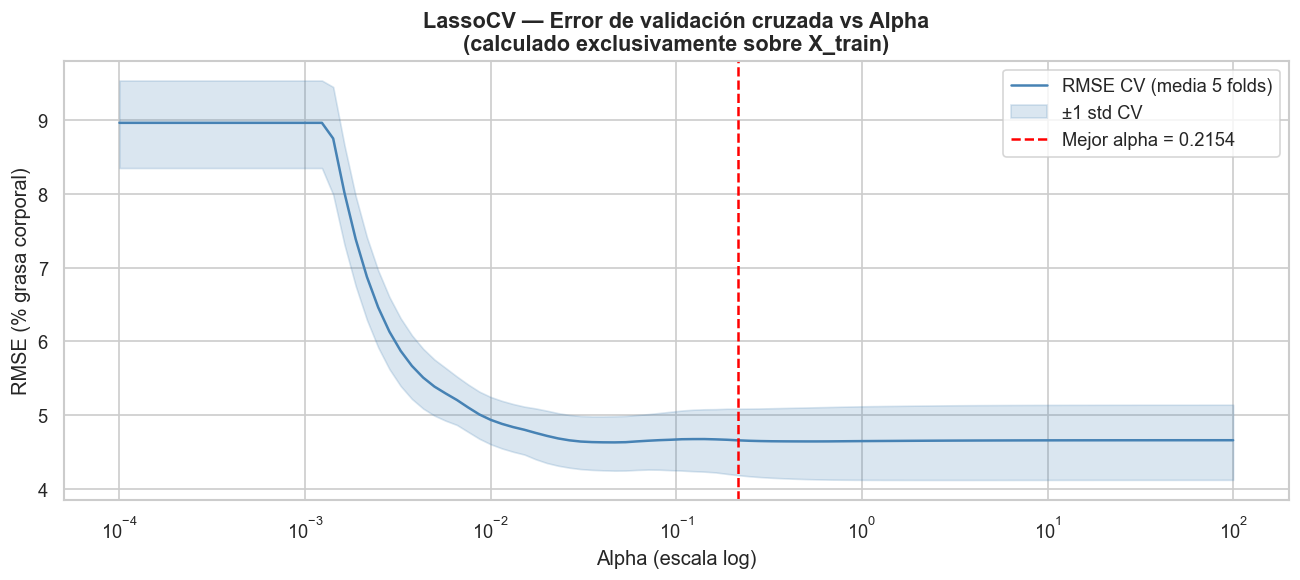

In [25]:
# ── Visualización del error de CV en función de alpha ─────────────────────────
# lasso_cv.mse_path_ tiene shape (n_alphas, n_folds)
mse_cv_mean = lasso_cv.mse_path_.mean(axis=1)  # promedio sobre los 5 folds
mse_cv_std  = lasso_cv.mse_path_.std(axis=1)
 
fig, ax = plt.subplots(figsize=(11, 5))
 
ax.plot(alphas_grid, np.sqrt(mse_cv_mean), color='steelblue', label='RMSE CV (media 5 folds)')
ax.fill_between(alphas_grid,
                np.sqrt(mse_cv_mean - mse_cv_std),
                np.sqrt(mse_cv_mean + mse_cv_std),
                alpha=0.2, color='steelblue', label='±1 std CV')
ax.axvline(best_alpha, color='red', linestyle='--', linewidth=1.5,
           label=f'Mejor alpha = {best_alpha:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (escala log)', fontsize=12)
ax.set_ylabel('RMSE (% grasa corporal)', fontsize=12)
ax.set_title('LassoCV — Error de validación cruzada vs Alpha\n(calculado exclusivamente sobre X_train)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# ── Entrenamiento del Lasso final con el alpha óptimo ────────────────────────
# Ahora entrenamos un Lasso con todo X_train usando el alpha elegido por CV.
lasso_best = Lasso(alpha=best_alpha, random_state=42, max_iter=20000)
lasso_best.fit(X_train_scaled, y_train)
 
y_pred_lasso_train = lasso_best.predict(X_train_scaled)
# ⚠️ Evaluación en test SOLO para registrar métricas finales — no se usó para elegir alpha
y_pred_lasso_test  = lasso_best.predict(X_test_scaled)
 
print(f'=== Lasso (alpha óptimo por CV = {best_alpha:.4f}) ===')
print('Train:')
res_lasso_train = evaluar_modelo(f'Lasso α={best_alpha:.4f} (train)', y_train, y_pred_lasso_train)
print('Test:')
res_lasso_test  = evaluar_modelo(f'Lasso α={best_alpha:.4f} (test)',  y_test,  y_pred_lasso_test)
resultados.append(res_lasso_test)
 
n_nonzero = (lasso_best.coef_ != 0).sum()
print(f'\n  Coeficientes NO nulos: {n_nonzero} / {len(lasso_best.coef_)}')

=== Lasso (alpha óptimo por CV = 0.2154) ===
Train:
  Lasso α=0.2154 (train)                    RMSE: 4.3739  |  MAE: 3.6434  |  R²: 0.7552
Test:
  Lasso α=0.2154 (test)                     RMSE: 4.6036  |  MAE: 3.4454  |  R²: 0.5294

  Coeficientes NO nulos: 5 / 13


=== Coeficientes Lasso (ordenados por magnitud absoluta) ===
Feature  Coeficiente
Abdomen     7.935580
  Wrist    -1.293558
 Height    -0.924899
    Age     0.650099
  Ankle     0.004690
  Chest    -0.000000
   Neck    -0.000000
 Weight    -0.000000
    Hip    -0.000000
   Knee     0.000000
  Thigh     0.000000
 Biceps     0.000000
Forearm     0.000000


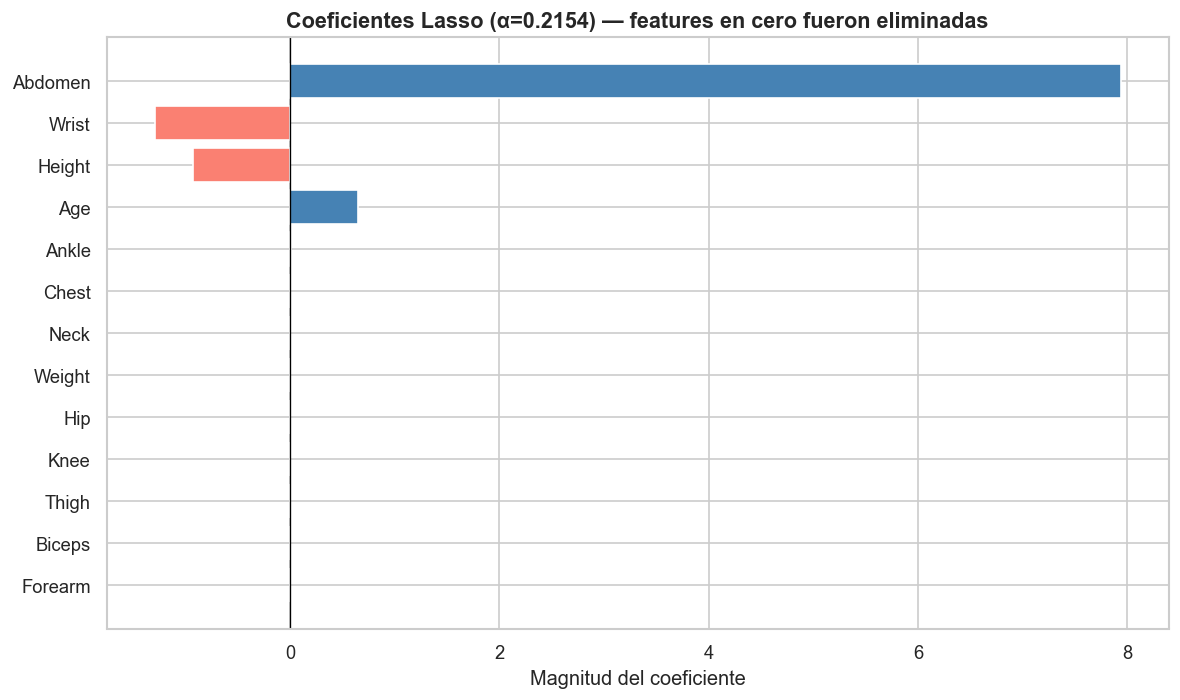


  Features eliminadas por Lasso (coef=0): ['Chest', 'Neck', 'Weight', 'Hip', 'Knee', 'Thigh', 'Biceps', 'Forearm']


In [27]:
# ── Coeficientes del modelo Lasso ─────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coeficiente': lasso_best.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
 
print('=== Coeficientes Lasso (ordenados por magnitud absoluta) ===')
print(coef_df.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Coeficientes Lasso (α={best_alpha:.4f}) — features en cero fueron eliminadas',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Magnitud del coeficiente')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
 
elim = coef_df[coef_df['Coeficiente'] == 0]['Feature'].tolist()
print(f'\n  Features eliminadas por Lasso (coef=0): {elim}')

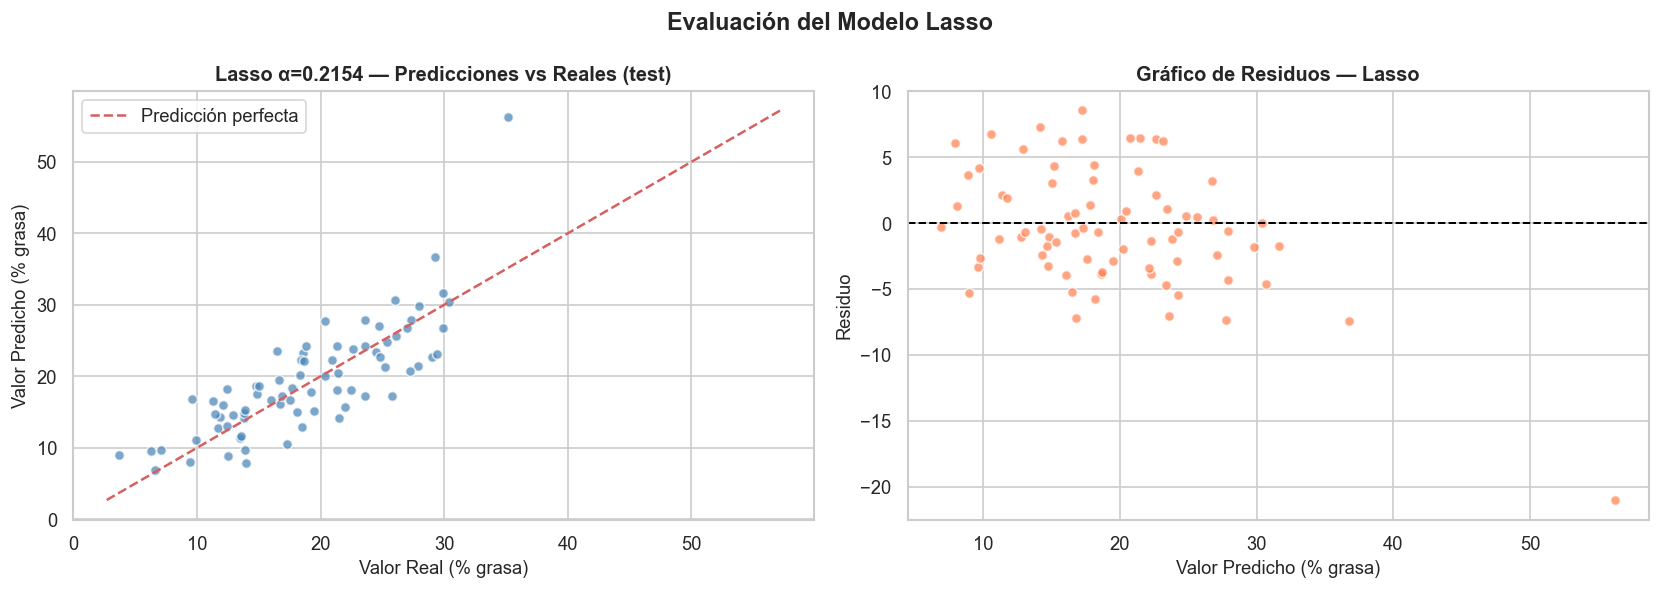

  Residuo medio   : -0.3859
  Residuo std     : 4.6179
  Residuo máx abs : 21.0166


In [28]:
# ── Gráfico: Predicciones vs Valores Reales — Lasso best ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Pred vs Real
ax = axes[0]
ax.scatter(y_test, y_pred_lasso_test, alpha=0.7, s=35, color='steelblue', edgecolors='white')
lims = [min(y_test.min(), y_pred_lasso_test.min()) - 1,
        max(y_test.max(), y_pred_lasso_test.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)', fontsize=11)
ax.set_ylabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_title(f'Lasso α={best_alpha:.4f} — Predicciones vs Reales (test)', fontsize=12, fontweight='bold')
ax.legend()
 
# Residuos
residuos_lasso = y_test - y_pred_lasso_test
ax = axes[1]
ax.scatter(y_pred_lasso_test, residuos_lasso, alpha=0.7, s=35, color='coral', edgecolors='white')
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_ylabel('Residuo', fontsize=11)
ax.set_title('Gráfico de Residuos — Lasso', fontsize=12, fontweight='bold')
 
plt.suptitle('Evaluación del Modelo Lasso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
print(f'  Residuo medio   : {residuos_lasso.mean():.4f}')
print(f'  Residuo std     : {residuos_lasso.std():.4f}')
print(f'  Residuo máx abs : {residuos_lasso.abs().max():.4f}')

=== Resumen de modelos — Fase 4 ===
               Modelo   RMSE    MAE      R²
Lasso α=0.2154 (test) 4.6036 3.4454  0.5294
         Dummy (test) 6.7151 5.5959 -0.0014


C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\3260819325.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_f4['Modelo'], rotation=20, ha='right', fontsize=9)
C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\3260819325.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_f4['Modelo'], rotation=20, ha='right', fontsize=9)
C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\3260819325.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_f4['Modelo'], rotation=20, ha='right', fontsize=9)


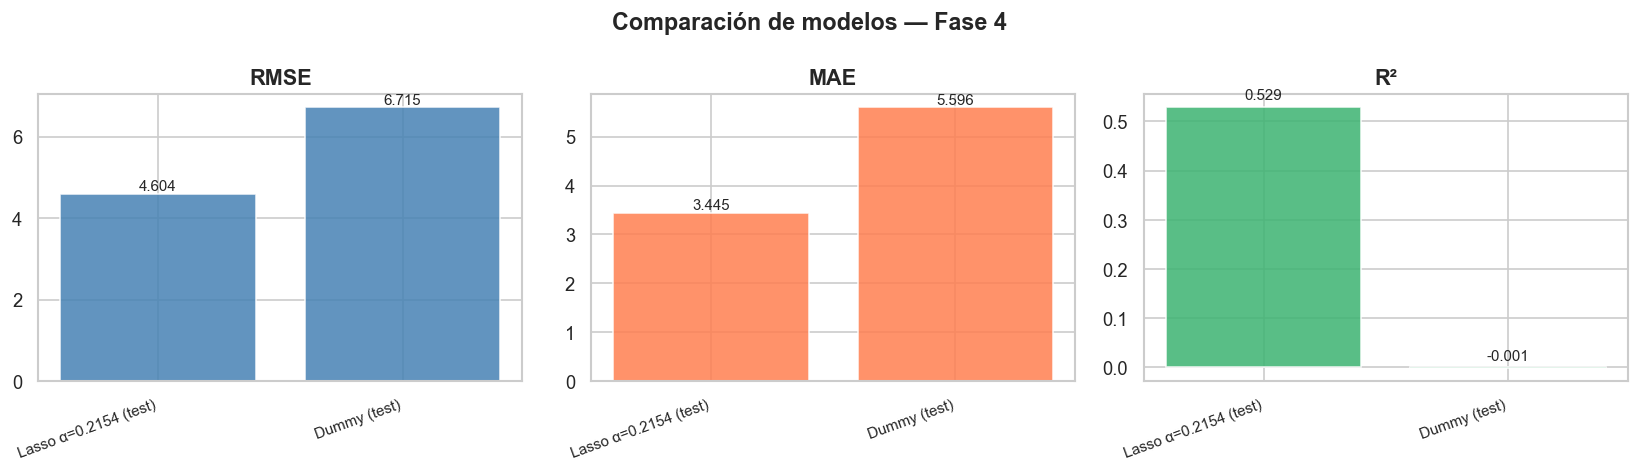

In [29]:
# ── Tabla resumen de modelos Fase 4 ──────────────────────────────────────────
resumen_f4 = pd.DataFrame(resultados).sort_values('RMSE')
 
print('=== Resumen de modelos — Fase 4 ===')
print(resumen_f4.to_string(index=False))
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metricas = ['RMSE', 'MAE', 'R²']
colores  = ['steelblue', 'coral', 'mediumseagreen']
 
for i, (metrica, color) in enumerate(zip(metricas, colores)):
    ax = axes[i]
    bars = ax.bar(resumen_f4['Modelo'], resumen_f4[metrica], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xticklabels(resumen_f4['Modelo'], rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, resumen_f4[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
 
plt.suptitle('Comparación de modelos — Fase 4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## FASE 5: Algoritmos No Lineales y Ensambles
 
En esta fase exploramos modelos capaces de capturar relaciones **no lineales** entre las  
variables corporales y el porcentaje de grasa. Mientras que Lasso asume linealidad,  
los modelos de esta fase pueden aprender curvas e interacciones sin que el analista las  
especifique manualmente.
 
**Protocolo de búsqueda de hiperparámetros:**  
Todos los hiperparámetros se buscan con `GridSearchCV` sobre **X_train_scaled** usando 5-fold CV.  
El set de test permanece completamente intacto hasta la Fase 6.
 
### 16. Support Vector Regressor (SVR)
 
SVR busca un hiperplano que contenga a la mayoría de los puntos dentro de un margen ε  
(epsilon-insensitive tube). Penaliza solo los puntos que quedan fuera del tubo.  
- **Kernel lineal**: equivalente a una regresión lineal penalizada; útil como referencia.  
- **Kernel RBF** (Radial Basis Function): proyecta los datos a un espacio de alta dimensión,  
  permitiendo capturar relaciones no lineales. Es el kernel más usado en la práctica.

In [30]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
 
# ── Búsqueda de hiperparámetros SVR — SOLO sobre train ─────────────────────
# Parámetros a explorar:
#   C      : parámetro de regularización (penaliza errores fuera del tubo ε)
#   epsilon: ancho del tubo insensible al error
#   kernel : tipo de función kernel
 
param_grid_svr = {
    'kernel' : ['linear', 'rbf'],
    'C'      : [0.1, 1, 10, 50],
    'epsilon': [0.1, 0.5, 1.0]
}
 
svr_gs = GridSearchCV(
    SVR(),
    param_grid_svr,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
svr_gs.fit(X_train_scaled, y_train)
 
print(f'✅ Mejores hiperparámetros SVR (CV sobre train): {svr_gs.best_params_}')
print(f'   RMSE CV (train): {-svr_gs.best_score_:.4f}')

✅ Mejores hiperparámetros SVR (CV sobre train): {'C': 50, 'epsilon': 1.0, 'kernel': 'linear'}
   RMSE CV (train): 4.9103


In [31]:
# ── Modelo SVR final con los mejores hiperparámetros ──────────────────────────
svr_best = svr_gs.best_estimator_
 
y_pred_svr_train = svr_best.predict(X_train_scaled)
y_pred_svr_test  = svr_best.predict(X_test_scaled)
 
print(f'=== SVR (kernel={svr_gs.best_params_["kernel"]}, C={svr_gs.best_params_["C"]}, '
      f'ε={svr_gs.best_params_["epsilon"]}) ===')
print('Train:')
res_svr_train = evaluar_modelo('SVR (train)', y_train, y_pred_svr_train)
print('Test:')
res_svr_test  = evaluar_modelo('SVR (test)',  y_test,  y_pred_svr_test)
resultados.append(res_svr_test)

=== SVR (kernel=linear, C=50, ε=1.0) ===
Train:
  SVR (train)                               RMSE: 4.2407  |  MAE: 3.4143  |  R²: 0.7699
Test:
  SVR (test)                                RMSE: 4.9415  |  MAE: 4.0105  |  R²: 0.4577


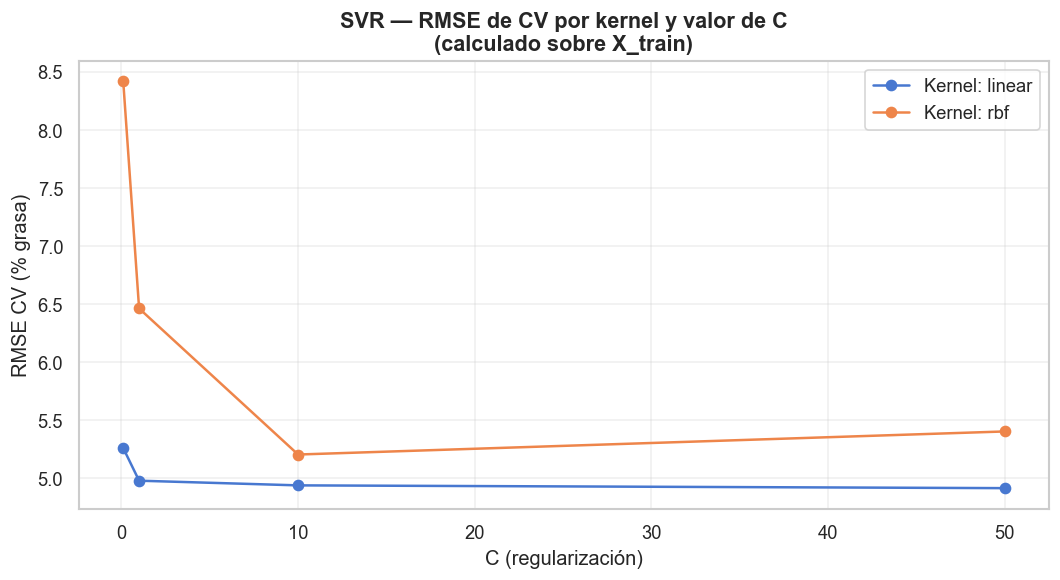

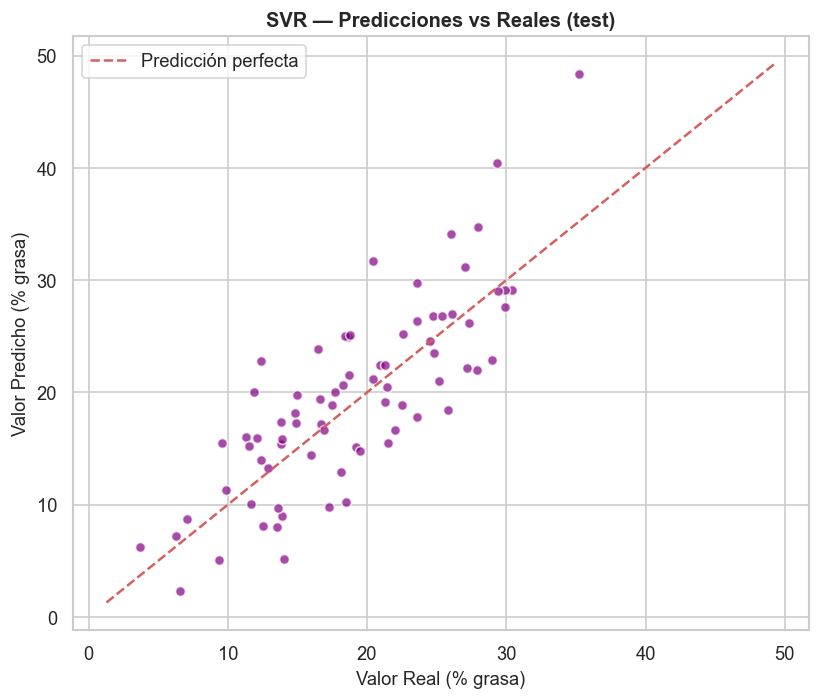

In [32]:
# ── Comparación de kernels SVR ────────────────────────────────────────────────
# Extraemos los RMSE CV de cada combinación kernel + C para visualizar el efecto
cv_results_svr = pd.DataFrame(svr_gs.cv_results_)
cv_results_svr['RMSE_CV'] = -cv_results_svr['mean_test_score']
 
pivot_svr = cv_results_svr.pivot_table(
    index='param_C', columns='param_kernel', values='RMSE_CV', aggfunc='min'
)
 
fig, ax = plt.subplots(figsize=(9, 5))
for kernel in pivot_svr.columns:
    ax.plot(pivot_svr.index, pivot_svr[kernel], 'o-', label=f'Kernel: {kernel}')
ax.set_xlabel('C (regularización)', fontsize=12)
ax.set_ylabel('RMSE CV (% grasa)', fontsize=12)
ax.set_title('SVR — RMSE de CV por kernel y valor de C\n(calculado sobre X_train)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
# Predicciones vs Reales — SVR
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_svr_test, alpha=0.7, s=35, color='purple', edgecolors='white')
lims = [min(y_test.min(), y_pred_svr_test.min()) - 1,
        max(y_test.max(), y_pred_svr_test.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)', fontsize=11)
ax.set_ylabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_title('SVR — Predicciones vs Reales (test)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 17. Random Forest Regressor
 
Random Forest construye múltiples árboles de decisión en paralelo, cada uno entrenado  
sobre una muestra bootstrap del dataset y usando un subconjunto aleatorio de features  
en cada split. La predicción final es el **promedio** de todos los árboles.
 
Ventajas clave:  
- Reduce la varianza respecto a un árbol individual (bagging).  
- Maneja multicolinealidad bien gracias a la selección aleatoria de features.  
- No requiere escalado (aunque usamos los datos escalados por consistencia con el pipeline).  
- Provee importancia de features de forma nativa.
 
Hiperparámetros principales a tunear:  
- `n_estimators`: cantidad de árboles (más es mejor hasta cierto punto).  
- `max_depth`: profundidad máxima de cada árbol (controla sobreajuste).  
- `min_samples_split`: mínimo de muestras para dividir un nodo (regularización).

In [33]:
from sklearn.ensemble import RandomForestRegressor
 
# ── Búsqueda de hiperparámetros RF — SOLO sobre train ──────────────────────
param_grid_rf = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
 
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
rf_gs.fit(X_train_scaled, y_train)
 
print(f'✅ Mejores hiperparámetros RF (CV sobre train): {rf_gs.best_params_}')
print(f'   RMSE CV (train): {-rf_gs.best_score_:.4f}')

✅ Mejores hiperparámetros RF (CV sobre train): {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
   RMSE CV (train): 4.8784


In [34]:
# ── Modelo RF final con los mejores hiperparámetros ───────────────────────────
rf_best = rf_gs.best_estimator_
 
y_pred_rf_train = rf_best.predict(X_train_scaled)
y_pred_rf_test  = rf_best.predict(X_test_scaled)
 
bp_rf = rf_gs.best_params_
print(f'=== Random Forest (n_est={bp_rf["n_estimators"]}, '
      f'max_depth={bp_rf["max_depth"]}, '
      f'min_split={bp_rf["min_samples_split"]}) ===')
print('Train:')
res_rf_train = evaluar_modelo('Random Forest (train)', y_train, y_pred_rf_train)
print('Test:')
res_rf_test  = evaluar_modelo('Random Forest (test)',  y_test,  y_pred_rf_test)
resultados.append(res_rf_test)

=== Random Forest (n_est=100, max_depth=10, min_split=5) ===
Train:
  Random Forest (train)                     RMSE: 2.1041  |  MAE: 1.6368  |  R²: 0.9433
Test:
  Random Forest (test)                      RMSE: 4.6214  |  MAE: 3.8800  |  R²: 0.5257


=== Importancia de features — Random Forest ===
Feature  Importancia
Abdomen     0.757735
 Height     0.053236
 Weight     0.022643
  Ankle     0.021739
  Wrist     0.021306
    Age     0.020470
   Neck     0.017815
Forearm     0.016024
  Thigh     0.015226
    Hip     0.014818
   Knee     0.014584
  Chest     0.013176
 Biceps     0.011227


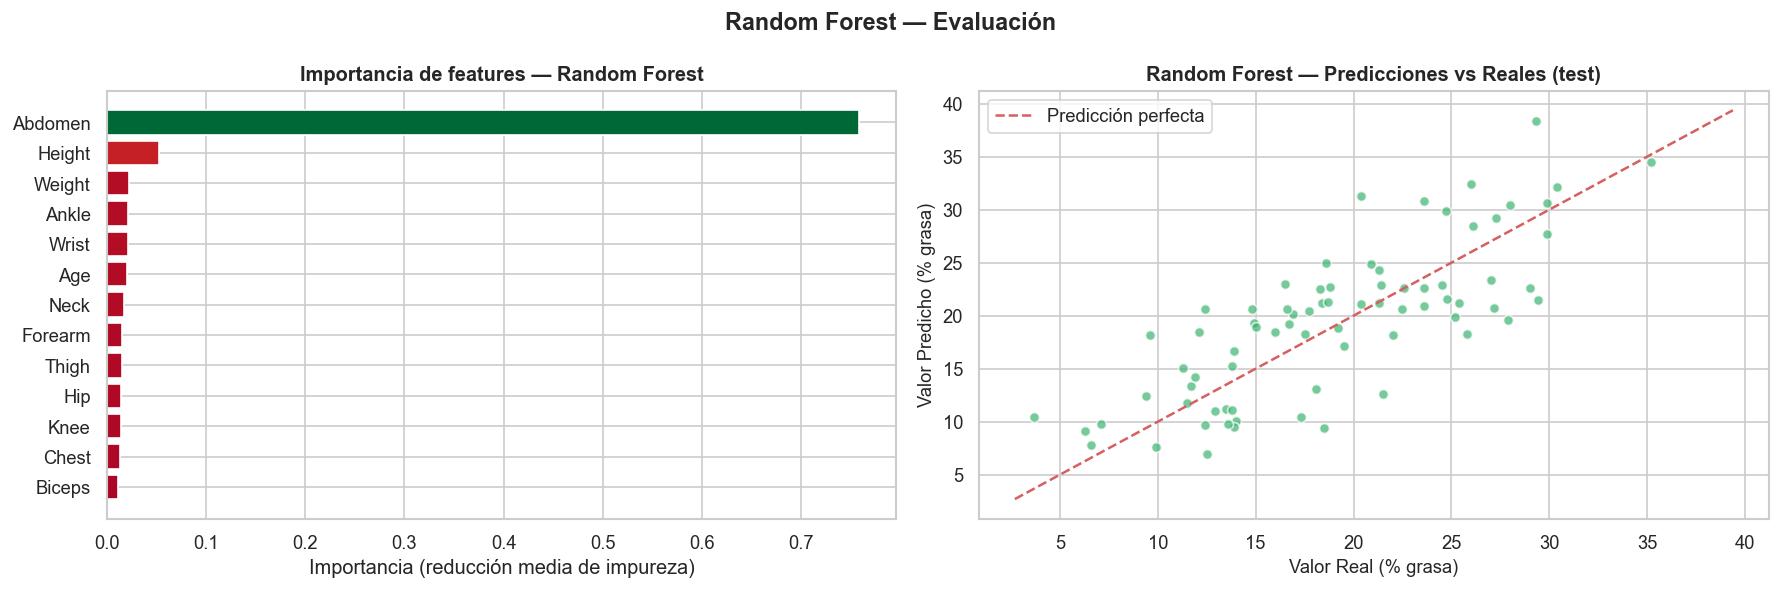

In [35]:
# ── Importancia de features — Random Forest ───────────────────────────────────
importances_rf = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Importancia': rf_best.feature_importances_
}).sort_values('Importancia', ascending=False)
 
print('=== Importancia de features — Random Forest ===')
print(importances_rf.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Importancias
ax = axes[0]
colors_rf = plt.cm.RdYlGn(importances_rf['Importancia'].values / importances_rf['Importancia'].max())
ax.barh(importances_rf['Feature'], importances_rf['Importancia'],
        color=colors_rf, edgecolor='white')
ax.set_title('Importancia de features — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (reducción media de impureza)')
ax.invert_yaxis()
 
# Pred vs Real
ax = axes[1]
ax.scatter(y_test, y_pred_rf_test, alpha=0.7, s=35, color='mediumseagreen', edgecolors='white')
lims = [min(y_test.min(), y_pred_rf_test.min()) - 1,
        max(y_test.max(), y_pred_rf_test.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)', fontsize=11)
ax.set_ylabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_title('Random Forest — Predicciones vs Reales (test)', fontsize=12, fontweight='bold')
ax.legend()
 
plt.suptitle('Random Forest — Evaluación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 18. Gradient Boosting — HistGradientBoostingRegressor
 
A diferencia de Random Forest (bagging), Gradient Boosting construye árboles de forma  
**secuencial**: cada árbol corrige los errores del anterior minimizando el gradiente  
de la función de pérdida.
 
Usamos `HistGradientBoostingRegressor` de scikit-learn porque:  
- Es mucho más eficiente que `GradientBoostingRegressor` (binning de histogramas).  
- Maneja nativamente valores faltantes (aunque aquí no los tenemos).  
- Escala bien a datasets más grandes.
 
Hiperparámetros clave:  
- `max_iter`: número de árboles (análogo a `n_estimators` en GBM).  
- `learning_rate`: tasa de aprendizaje; valores pequeños + más árboles = mejor generalización.  
- `max_depth`: profundidad máxima de cada árbol base.

In [36]:
from sklearn.ensemble import HistGradientBoostingRegressor
 
# ── Búsqueda de hiperparámetros HGB — SOLO sobre train ─────────────────────
param_grid_hgb = {
    'max_iter'     : [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth'    : [3, 5, None]
}
 
hgb_gs = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid_hgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
hgb_gs.fit(X_train_scaled, y_train)
 
print(f'✅ Mejores hiperparámetros HGB (CV sobre train): {hgb_gs.best_params_}')
print(f'   RMSE CV (train): {-hgb_gs.best_score_:.4f}')

✅ Mejores hiperparámetros HGB (CV sobre train): {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100}
   RMSE CV (train): 5.0084


In [37]:
# ── Modelo HGB final con los mejores hiperparámetros ──────────────────────────
hgb_best = hgb_gs.best_estimator_
 
y_pred_hgb_train = hgb_best.predict(X_train_scaled)
y_pred_hgb_test  = hgb_best.predict(X_test_scaled)
 
bp_hgb = hgb_gs.best_params_
print(f'=== HistGradientBoosting (iter={bp_hgb["max_iter"]}, '
      f'lr={bp_hgb["learning_rate"]}, '
      f'max_depth={bp_hgb["max_depth"]}) ===')
print('Train:')
res_hgb_train = evaluar_modelo('HGBoost (train)', y_train, y_pred_hgb_train)
print('Test:')
res_hgb_test  = evaluar_modelo('HGBoost (test)',  y_test,  y_pred_hgb_test)
resultados.append(res_hgb_test)

=== HistGradientBoosting (iter=100, lr=0.05, max_depth=3) ===
Train:
  HGBoost (train)                           RMSE: 3.1286  |  MAE: 2.4762  |  R²: 0.8747
Test:
  HGBoost (test)                            RMSE: 4.3757  |  MAE: 3.5819  |  R²: 0.5748


=== Importancia por permutación — HGB (sobre train) ===
Feature  Importancia      Std
Abdomen     1.505967 0.120910
    Age     0.047365 0.008924
 Height     0.045432 0.007169
  Wrist     0.044056 0.006455
    Hip     0.021263 0.003126
  Thigh     0.015993 0.002852
   Neck     0.012455 0.002411
 Weight     0.008885 0.001983
 Biceps     0.004566 0.001415
   Knee     0.004427 0.001295
  Ankle     0.003845 0.000736
  Chest     0.001922 0.000759
Forearm     0.000588 0.000150


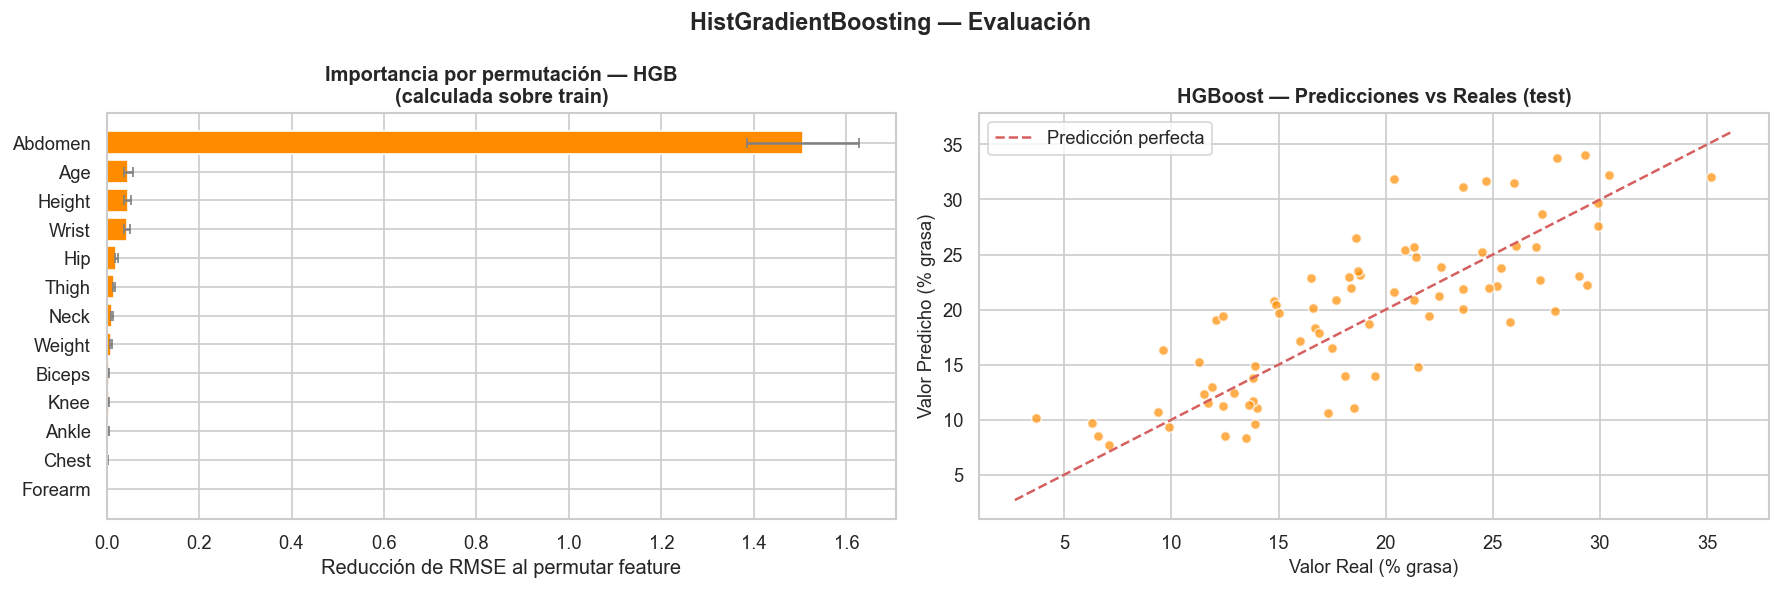

In [38]:
# ── Importancia de features — HistGradientBoosting (permutation) ──────────────
# HGB no provee feature_importances_ nativo del mismo tipo que RF.
# Usamos permutation importance sobre el set de TRAIN para mantener el test intacto.
from sklearn.inspection import permutation_importance
 
perm_imp = permutation_importance(
    hgb_best, X_train_scaled, y_train,
    n_repeats=20, random_state=42, n_jobs=-1
)
 
imp_hgb_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importancia': perm_imp.importances_mean,
    'Std'        : perm_imp.importances_std
}).sort_values('Importancia', ascending=False)
 
print('=== Importancia por permutación — HGB (sobre train) ===')
print(imp_hgb_df.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Importancias con barras de error
ax = axes[0]
ax.barh(imp_hgb_df['Feature'], imp_hgb_df['Importancia'],
        xerr=imp_hgb_df['Std'], color='darkorange', edgecolor='white',
        ecolor='gray', capsize=3)
ax.set_title('Importancia por permutación — HGB\n(calculada sobre train)', fontsize=12, fontweight='bold')
ax.set_xlabel('Reducción de RMSE al permutar feature')
ax.invert_yaxis()
 
# Pred vs Real
ax = axes[1]
ax.scatter(y_test, y_pred_hgb_test, alpha=0.7, s=35, color='darkorange', edgecolors='white')
lims = [min(y_test.min(), y_pred_hgb_test.min()) - 1,
        max(y_test.max(), y_pred_hgb_test.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)', fontsize=11)
ax.set_ylabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_title('HGBoost — Predicciones vs Reales (test)', fontsize=12, fontweight='bold')
ax.legend()
 
plt.suptitle('HistGradientBoosting — Evaluación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== Resumen acumulado — Fases 4 y 5 (evaluado en test) ===
               Modelo   RMSE    MAE      R²
       HGBoost (test) 4.3757 3.5819  0.5748
Lasso α=0.2154 (test) 4.6036 3.4454  0.5294
 Random Forest (test) 4.6214 3.8800  0.5257
           SVR (test) 4.9415 4.0105  0.4577
         Dummy (test) 6.7151 5.5959 -0.0014


C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\709578574.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_total['Modelo'], rotation=25, ha='right', fontsize=8)
C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\709578574.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_total['Modelo'], rotation=25, ha='right', fontsize=8)
C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\709578574.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_total['Modelo'], rotation=25, ha='right', fontsize=8)


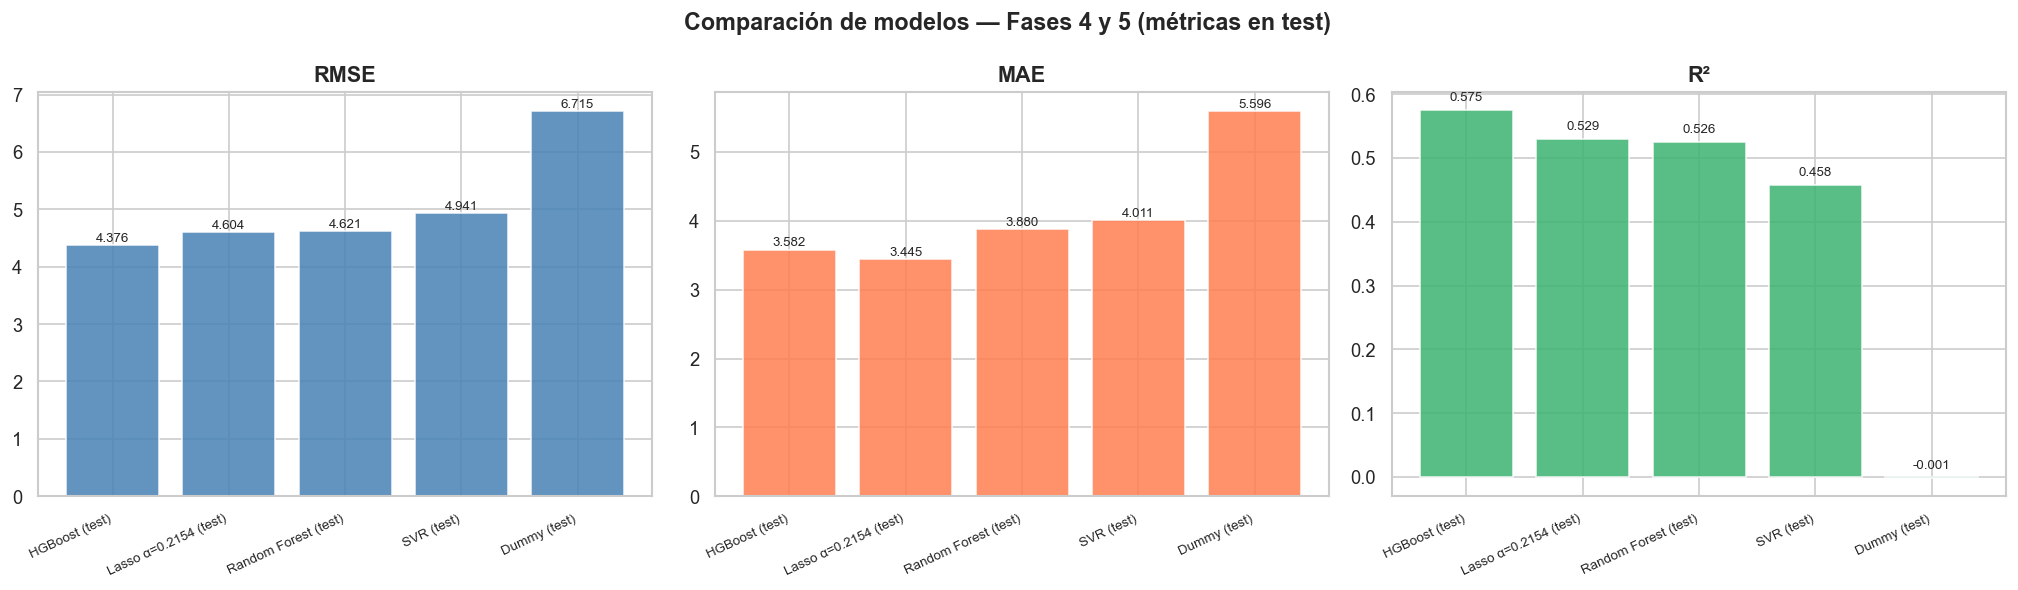

In [39]:
# ── Tabla resumen de modelos Fases 4 y 5 ──────────────────────────────────────
resumen_total = pd.DataFrame(resultados).sort_values('RMSE')
 
print('=== Resumen acumulado — Fases 4 y 5 (evaluado en test) ===')
print(resumen_total.to_string(index=False))
 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metricas = ['RMSE', 'MAE', 'R²']
colores  = ['steelblue', 'coral', 'mediumseagreen']
 
for i, (metrica, color) in enumerate(zip(metricas, colores)):
    ax = axes[i]
    bars = ax.bar(resumen_total['Modelo'], resumen_total[metrica],
                  color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xticklabels(resumen_total['Modelo'], rotation=25, ha='right', fontsize=8)
    for bar, val in zip(bars, resumen_total[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
 
plt.suptitle('Comparación de modelos — Fases 4 y 5 (métricas en test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## FASE 6: Optimización y Validación Robusta
 
Con n=251 observaciones, la estimación de rendimiento sobre un único split de test  
puede ser **inestable**: una partición desafortunada puede favorecer o penalizar  
artificialmente a un modelo. En esta fase aplicamos técnicas de validación más robustas  
y realizamos la evaluación final sobre el test set intacto.
 
### 19. Validación Cruzada K-Fold sobre todos los modelos
 
Aplicamos `cross_val_score` con **k=10** sobre el set de entrenamiento para comparar  
todos los modelos con mayor solidez estadística.  
**Nota:** Dado que la búsqueda de hiperparámetros ya se hizo en la Fase anterior,  
aquí utilizamos los modelos ya optimizados para estimar su rendimiento real.

In [40]:
from sklearn.model_selection import cross_val_score, KFold
 
# ── Validación cruzada 10-fold sobre X_train_scaled ───────────────────────────
# Usamos los modelos ya optimizados. El test set NO se toca.
 
kf = KFold(n_splits=10, shuffle=True, random_state=42)
 
modelos_cv = {
    'Lasso (α óptimo)'  : lasso_best,
    'SVR'               : svr_best,
    'Random Forest'     : rf_best,
    'HGBoosting'        : hgb_best
}
 
print('=== Validación Cruzada 10-fold — RMSE sobre X_train ===')
print(f'  {"Modelo":<25}  {"RMSE Mean":>10}  {"RMSE Std":>10}  {"CV Scores (fold by fold)"}')
print('  ' + '-'*90)
 
cv_resultados = []
for nombre, modelo in modelos_cv.items():
    scores = cross_val_score(
        modelo, X_train_scaled, y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    rmse_scores = -scores
    cv_resultados.append({
        'Modelo': nombre,
        'RMSE Mean': round(rmse_scores.mean(), 4),
        'RMSE Std' : round(rmse_scores.std(),  4),
        'scores'   : rmse_scores
    })
    print(f'  {nombre:<25}  {rmse_scores.mean():>10.4f}  {rmse_scores.std():>10.4f}  '
          f'{[round(s,3) for s in rmse_scores]}')

=== Validación Cruzada 10-fold — RMSE sobre X_train ===
  Modelo                      RMSE Mean    RMSE Std  CV Scores (fold by fold)
  ------------------------------------------------------------------------------------------
  Lasso (α óptimo)               4.4675      0.5079  [np.float64(3.878), np.float64(3.832), np.float64(4.697), np.float64(3.667), np.float64(4.963), np.float64(4.379), np.float64(4.726), np.float64(4.432), np.float64(4.791), np.float64(5.309)]
  SVR                            4.7345      0.6351  [np.float64(3.965), np.float64(3.466), np.float64(5.068), np.float64(4.425), np.float64(5.685), np.float64(4.394), np.float64(4.922), np.float64(5.203), np.float64(5.297), np.float64(4.919)]
  Random Forest                  4.9175      0.5450  [np.float64(3.851), np.float64(4.59), np.float64(5.144), np.float64(4.364), np.float64(5.075), np.float64(5.841), np.float64(5.473), np.float64(4.6), np.float64(5.106), np.float64(5.132)]
  HGBoosting                     5.0630     

C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\3801951868.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(scores_cv, labels=nombres_cv, patch_artist=True,
C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\3801951868.py:24: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\ROA22468\AppData\Local\anaconda3\envs\ia_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


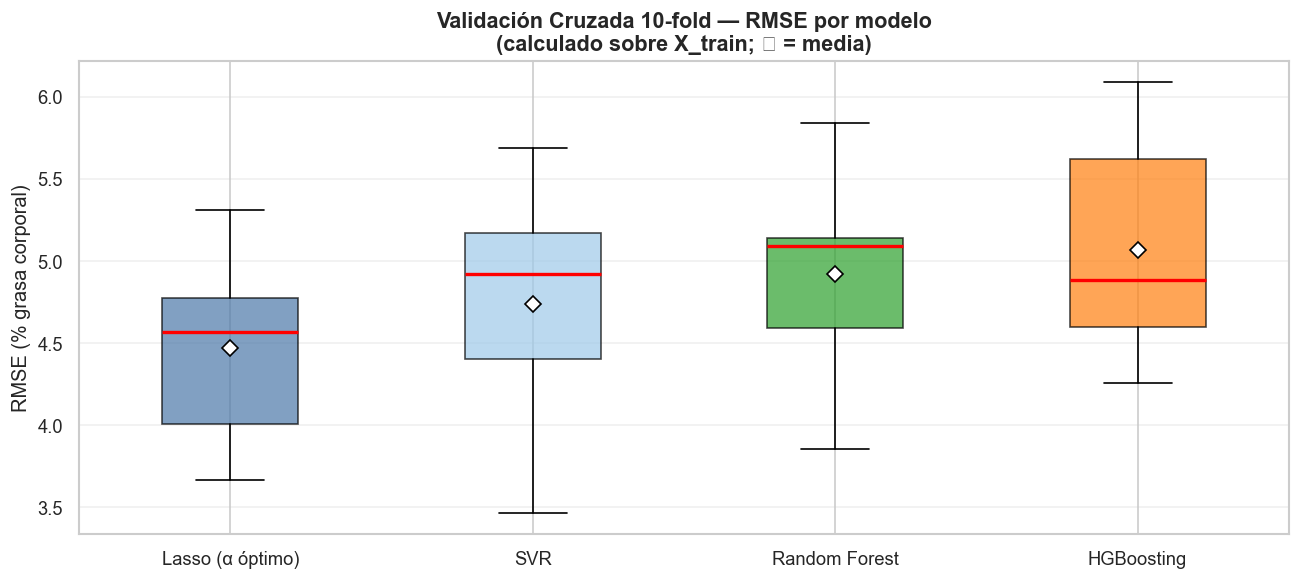


Interpretación:
  Cajas más angostas → menor varianza entre folds → estimación más estable.
  La media (◇) puede diferir de la mediana (línea roja) si hay folds atípicos.


In [41]:
# ── Boxplot comparativo de los RMSE en CV ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
 
nombres_cv  = [r['Modelo']  for r in cv_resultados]
scores_cv   = [r['scores']  for r in cv_resultados]
means_cv    = [r['RMSE Mean'] for r in cv_resultados]
 
bp = ax.boxplot(scores_cv, labels=nombres_cv, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
 
colores_box = ['#4C78A8', '#9ECAE9', '#2CA02C', '#FF7F0E']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
 
# Marcar la media con un punto
for i, mean in enumerate(means_cv, start=1):
    ax.plot(i, mean, 'D', color='white', markersize=7, markeredgecolor='black', zorder=3)
 
ax.set_ylabel('RMSE (% grasa corporal)', fontsize=12)
ax.set_title('Validación Cruzada 10-fold — RMSE por modelo\n(calculado sobre X_train; ◇ = media)',
             fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
 
print('\nInterpretación:')
print('  Cajas más angostas → menor varianza entre folds → estimación más estable.')
print('  La media (◇) puede diferir de la mediana (línea roja) si hay folds atípicos.')

### 20. Evaluación Final — Test Set Intacto
 
Llegamos a la instancia más importante del TP: evaluamos los modelos optimizados  
contra el **set de test que nunca se usó durante el entrenamiento ni la selección de hiperparámetros**.
 
Esta evaluación es la estimación más honesta del rendimiento en datos nuevos.

In [42]:
# ── Evaluación final sobre el TEST SET (intacto) ──────────────────────────────
print('=' * 75)
print('       EVALUACIÓN FINAL — TEST SET (70/30 split, set de test intacto)')
print('=' * 75)
print()
 
resultados_finales = []
 
preds_finales = {
    'Baseline (Dummy)'  : dummy.predict(X_test_scaled),
    'Lasso (α óptimo)'  : y_pred_lasso_test,
    'SVR'               : y_pred_svr_test,
    'Random Forest'     : y_pred_rf_test,
    'HGBoosting'        : y_pred_hgb_test,
}
 
for nombre, y_pred in preds_finales.items():
    res = evaluar_modelo(nombre, y_test, y_pred)
    resultados_finales.append(res)
 
print()
df_finales = pd.DataFrame(resultados_finales).sort_values('RMSE')
print('=== Ranking final por RMSE (test) ===')
print(df_finales.to_string(index=False))

       EVALUACIÓN FINAL — TEST SET (70/30 split, set de test intacto)

  Baseline (Dummy)                          RMSE: 6.7151  |  MAE: 5.5959  |  R²: -0.0014
  Lasso (α óptimo)                          RMSE: 4.6036  |  MAE: 3.4454  |  R²: 0.5294
  SVR                                       RMSE: 4.9415  |  MAE: 4.0105  |  R²: 0.4577
  Random Forest                             RMSE: 4.6214  |  MAE: 3.8800  |  R²: 0.5257
  HGBoosting                                RMSE: 4.3757  |  MAE: 3.5819  |  R²: 0.5748

=== Ranking final por RMSE (test) ===
          Modelo   RMSE    MAE      R²
      HGBoosting 4.3757 3.5819  0.5748
Lasso (α óptimo) 4.6036 3.4454  0.5294
   Random Forest 4.6214 3.8800  0.5257
             SVR 4.9415 4.0105  0.4577
Baseline (Dummy) 6.7151 5.5959 -0.0014


C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\3643990013.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted['Modelo'], rotation=25, ha='right', fontsize=9)
C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\3643990013.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted['Modelo'], rotation=25, ha='right', fontsize=9)
C:\Users\ROA22468\AppData\Local\Temp\ipykernel_3984\3643990013.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted['Modelo'], rotation=25, ha='right', fontsize=9)


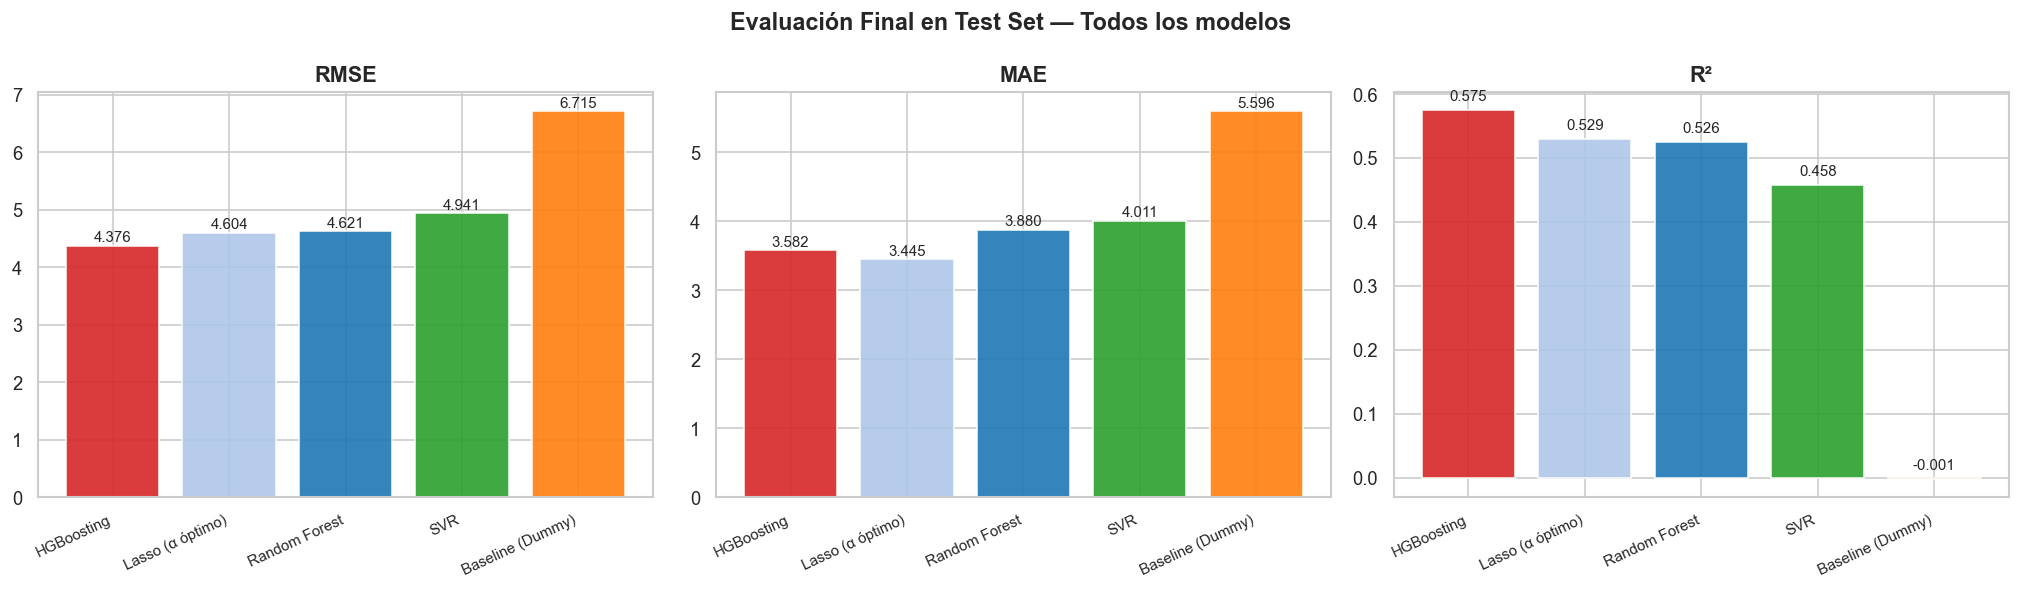

In [43]:
# ── Gráfico de ranking final ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metricas = ['RMSE', 'MAE', 'R²']
paleta   = ['#d62728', '#aec7e8', '#1f77b4', '#2ca02c', '#ff7f0e']
 
for i, metrica in enumerate(metricas):
    ax = axes[i]
    df_sorted = df_finales.sort_values('RMSE')  # mismo orden en todas las métricas
    bars = ax.bar(df_sorted['Modelo'], df_sorted[metrica],
                  color=paleta[:len(df_sorted)], edgecolor='white', alpha=0.9)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xticklabels(df_sorted['Modelo'], rotation=25, ha='right', fontsize=9)
    for bar, val in zip(bars, df_sorted[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
 
plt.suptitle('Evaluación Final en Test Set — Todos los modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# ── Identificar el mejor modelo ───────────────────────────────────────────────
mejor_modelo_nombre = df_finales.iloc[0]['Modelo']
mejor_rmse          = df_finales.iloc[0]['RMSE']
mejor_r2            = df_finales.iloc[0]['R²']
 
print(f'🏆 Mejor modelo: {mejor_modelo_nombre}')
print(f'   RMSE en test : {mejor_rmse:.4f} % de grasa corporal')
print(f'   R²   en test : {mejor_r2:.4f}')
print()
print(f'   Interpretación: en promedio el modelo se equivoca {mejor_rmse:.2f} puntos porcentuales')
print(f'   al predecir el porcentaje de grasa corporal.')
print(f'   El modelo explica el {mejor_r2*100:.1f}% de la varianza del target.')

🏆 Mejor modelo: HGBoosting
   RMSE en test : 4.3757 % de grasa corporal
   R²   en test : 0.5748

   Interpretación: en promedio el modelo se equivoca 4.38 puntos porcentuales
   al predecir el porcentaje de grasa corporal.
   El modelo explica el 57.5% de la varianza del target.


### 21. Análisis de Errores e Importancia de Variables
 
Verificamos que los residuos del mejor modelo sean **aleatorios** (sin patrones sistemáticos),  
lo que indicaría que el modelo capturó toda la señal disponible sin sesgo sistemático.

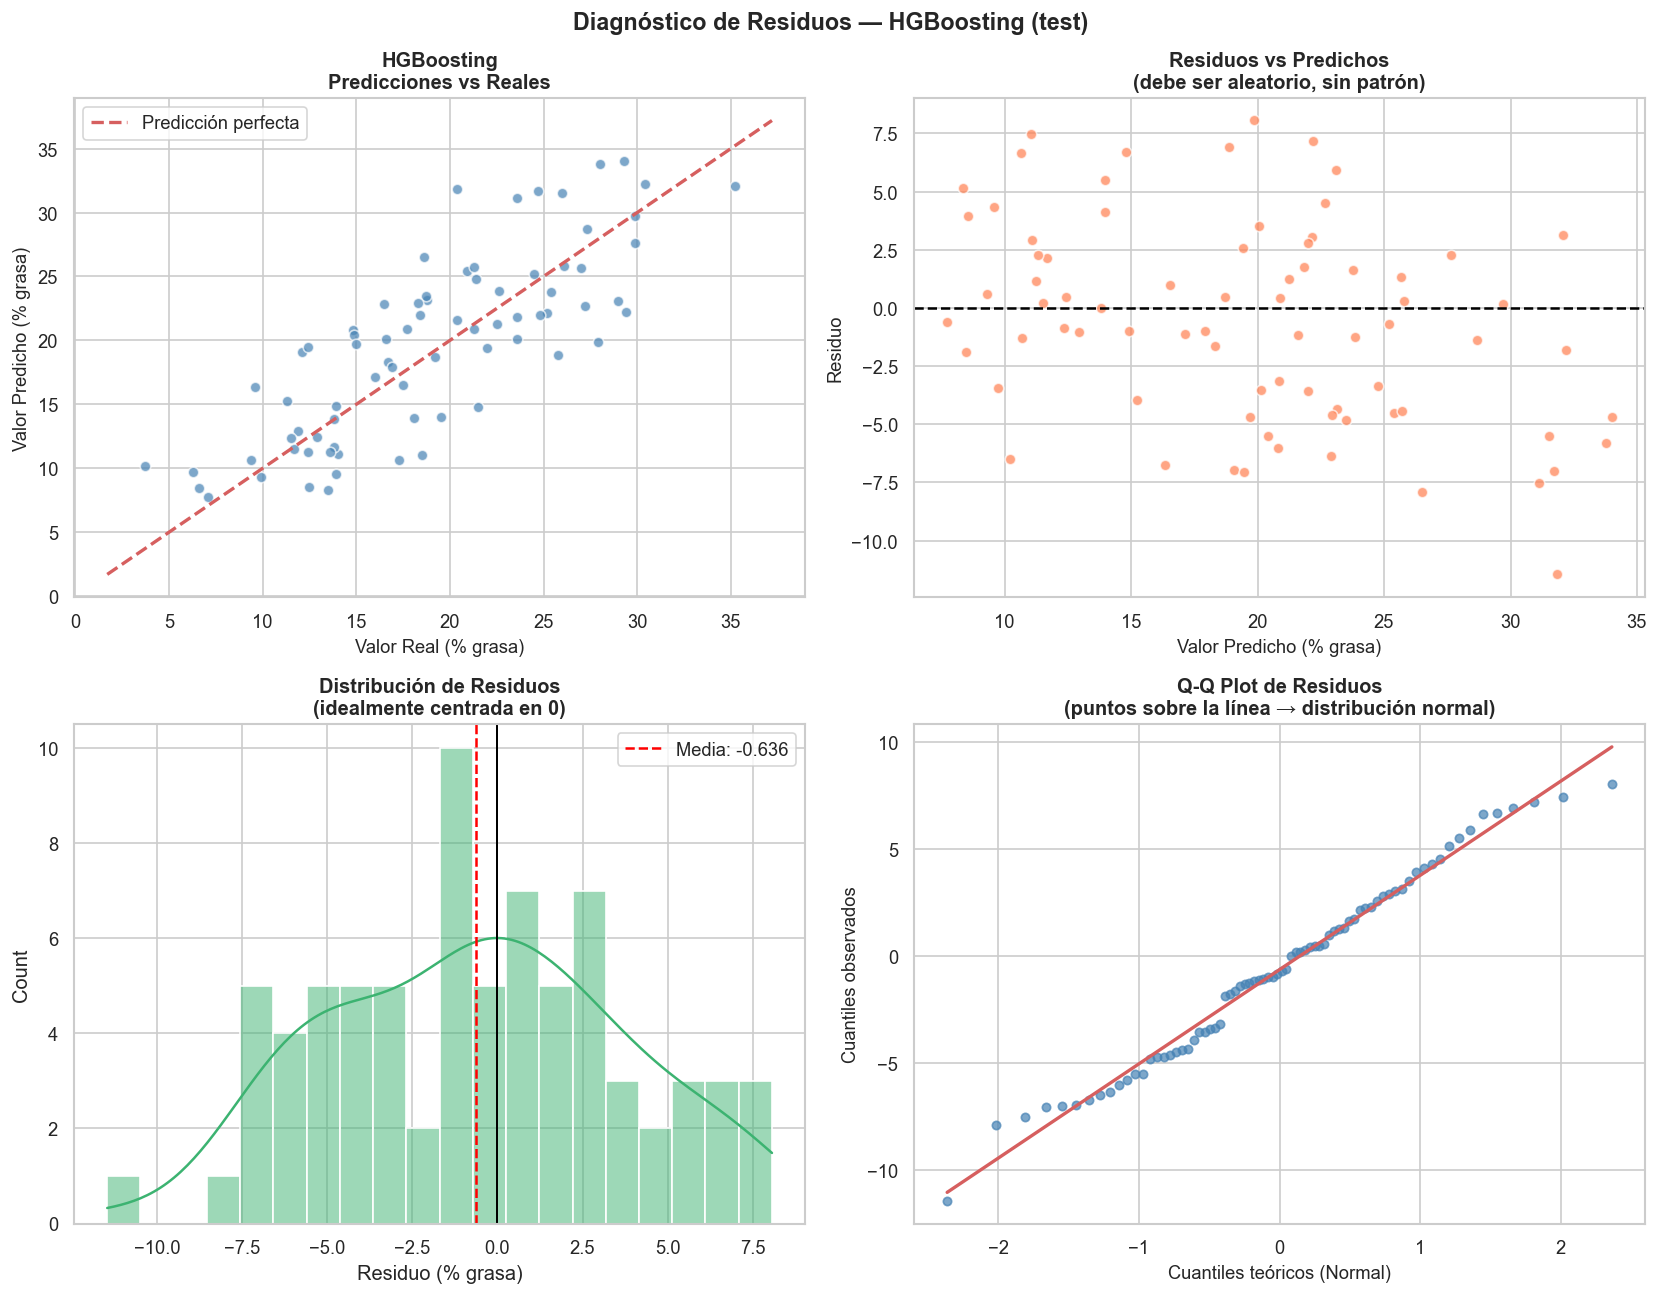

=== Estadísticas de residuos ===
  Media          : -0.6359  (≈0 indica sin sesgo)
  Desv. estándar : 4.3580
  Mínimo         : -11.4564
  Máximo         : 8.0569
  % residuos dentro de ±3%: 44.7%
  % residuos dentro de ±5%: 71.1%


In [45]:
# ── Seleccionar las predicciones del mejor modelo ────────────────────────────
mejor_pred = preds_finales[mejor_modelo_nombre]
residuos_final = y_test - mejor_pred
 
# ── Panel completo de diagnóstico de residuos ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
 
# 1. Predicciones vs Reales
ax = axes[0, 0]
ax.scatter(y_test, mejor_pred, alpha=0.7, s=40, color='steelblue', edgecolors='white')
lims = [min(y_test.min(), mejor_pred.min()) - 2, max(y_test.max(), mejor_pred.max()) + 2]
ax.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)', fontsize=11)
ax.set_ylabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_title(f'{mejor_modelo_nombre}\nPredicciones vs Reales', fontsize=12, fontweight='bold')
ax.legend()
 
# 2. Residuos vs Predichos
ax = axes[0, 1]
ax.scatter(mejor_pred, residuos_final, alpha=0.7, s=40, color='coral', edgecolors='white')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_ylabel('Residuo', fontsize=11)
ax.set_title('Residuos vs Predichos\n(debe ser aleatorio, sin patrón)', fontsize=12, fontweight='bold')
 
# 3. Histograma de residuos
ax = axes[1, 0]
sns.histplot(residuos_final, bins=20, kde=True, color='mediumseagreen',
             edgecolor='white', ax=ax)
ax.axvline(residuos_final.mean(), color='red', linestyle='--',
           label=f'Media: {residuos_final.mean():.3f}')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title('Distribución de Residuos\n(idealmente centrada en 0)', fontsize=12, fontweight='bold')
ax.set_xlabel('Residuo (% grasa)')
ax.legend()
 
# 4. Q-Q Plot (normalidad de residuos)
ax = axes[1, 1]
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuos_final, dist='norm')
ax.plot(osm, osr, 'o', color='steelblue', alpha=0.7, markersize=5)
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2)
ax.set_xlabel('Cuantiles teóricos (Normal)', fontsize=11)
ax.set_ylabel('Cuantiles observados', fontsize=11)
ax.set_title('Q-Q Plot de Residuos\n(puntos sobre la línea → distribución normal)',
             fontsize=12, fontweight='bold')
 
plt.suptitle(f'Diagnóstico de Residuos — {mejor_modelo_nombre} (test)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Estadísticas de residuos
print('=== Estadísticas de residuos ===')
print(f'  Media          : {residuos_final.mean():.4f}  (≈0 indica sin sesgo)')
print(f'  Desv. estándar : {residuos_final.std():.4f}')
print(f'  Mínimo         : {residuos_final.min():.4f}')
print(f'  Máximo         : {residuos_final.max():.4f}')
print(f'  % residuos dentro de ±3%: {(residuos_final.abs() <= 3).mean()*100:.1f}%')
print(f'  % residuos dentro de ±5%: {(residuos_final.abs() <= 5).mean()*100:.1f}%')

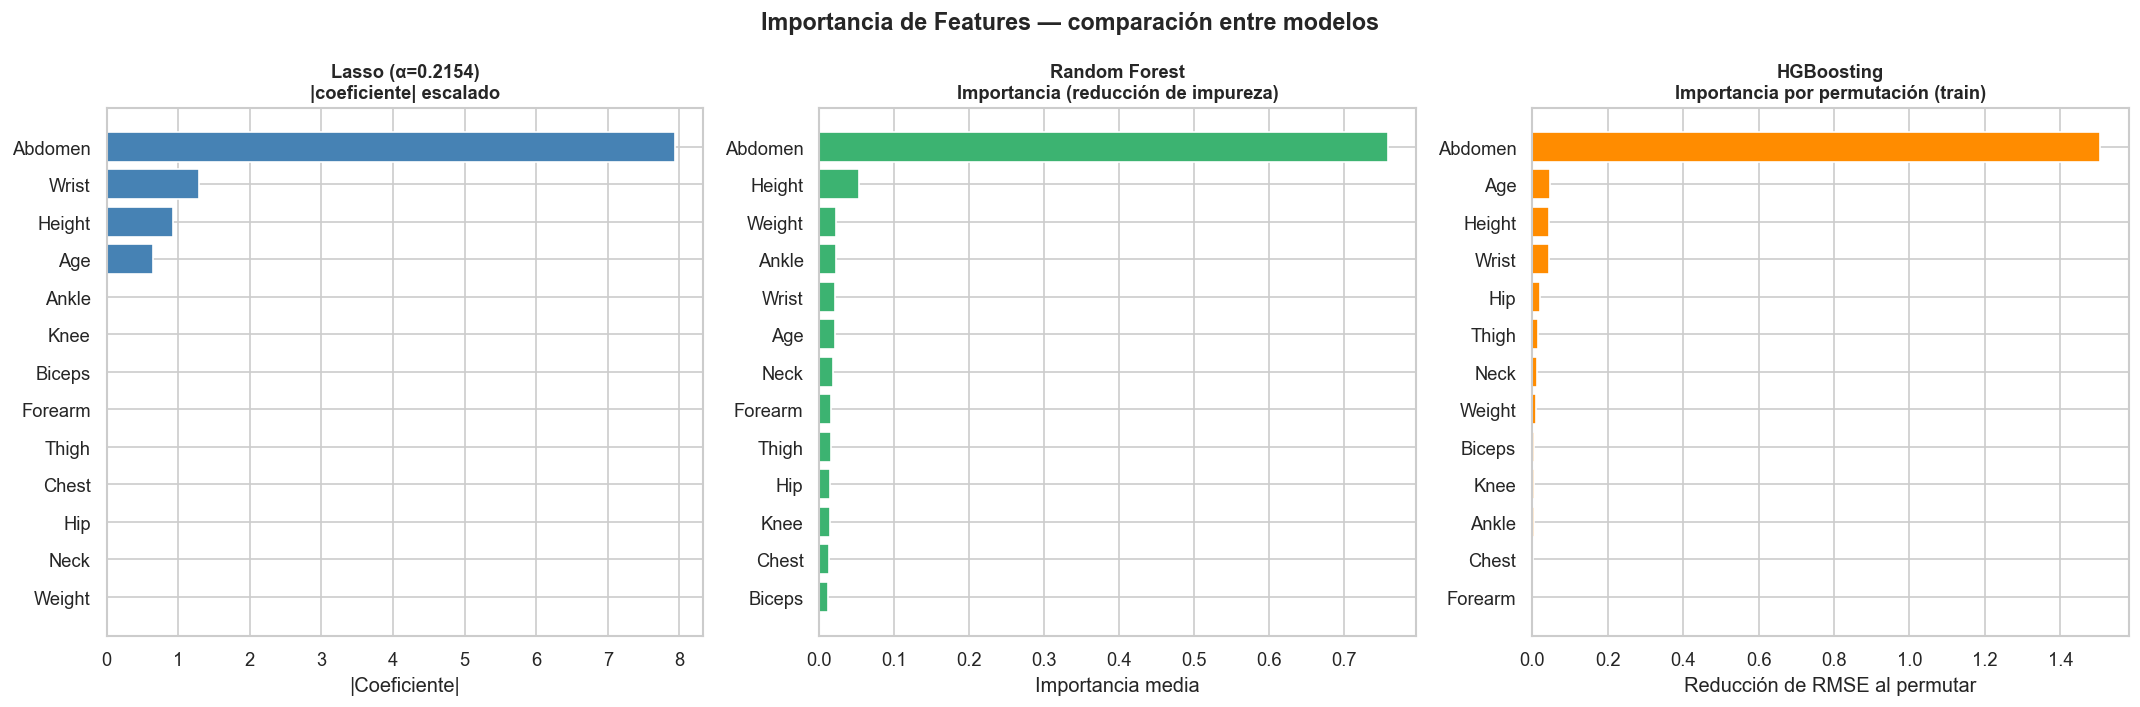


Top 5 Lasso    : ['Abdomen', 'Wrist', 'Height', 'Age', 'Ankle']
Top 5 RF       : ['Abdomen', 'Height', 'Weight', 'Ankle', 'Wrist']
Top 5 HGB      : ['Abdomen', 'Age', 'Height', 'Wrist', 'Hip']

🏅 Variables en el TOP 5 de los 3 modelos: ['Abdomen', 'Height', 'Wrist']


In [46]:
# ── Importancia de features — comparación entre modelos ──────────────────────
# Lasso: coeficientes absolutos (después de escalar → comparables)
# Random Forest: feature_importances_ (reducción de impureza)
# HGB: permutation importance calculada sobre train
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
# --- Lasso ---
ax = axes[0]
coef_abs = pd.Series(np.abs(lasso_best.coef_), index=X_train.columns).sort_values(ascending=True)
colors_lasso = ['salmon' if v == 0 else 'steelblue' for v in coef_abs.values]
ax.barh(coef_abs.index, coef_abs.values, color=colors_lasso, edgecolor='white')
ax.set_title(f'Lasso (α={best_alpha:.4f})\n|coeficiente| escalado', fontsize=11, fontweight='bold')
ax.set_xlabel('|Coeficiente|')
 
# --- Random Forest ---
ax = axes[1]
imp_rf = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values(ascending=True)
ax.barh(imp_rf.index, imp_rf.values, color='mediumseagreen', edgecolor='white')
ax.set_title('Random Forest\nImportancia (reducción de impureza)', fontsize=11, fontweight='bold')
ax.set_xlabel('Importancia media')
 
# --- HGB (permutation) ---
ax = axes[2]
imp_hgb = pd.Series(perm_imp.importances_mean, index=X_train.columns).sort_values(ascending=True)
ax.barh(imp_hgb.index, imp_hgb.values, color='darkorange', edgecolor='white')
ax.set_title('HGBoosting\nImportancia por permutación (train)', fontsize=11, fontweight='bold')
ax.set_xlabel('Reducción de RMSE al permutar')
 
plt.suptitle('Importancia de Features — comparación entre modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
# ── Variables consistentemente importantes en los 3 modelos ───────────────────
top_lasso = coef_abs[coef_abs > 0].sort_values(ascending=False).head(5).index.tolist()
top_rf    = imp_rf.sort_values(ascending=False).head(5).index.tolist()
top_hgb   = imp_hgb.sort_values(ascending=False).head(5).index.tolist()
 
consenso = set(top_lasso) & set(top_rf) & set(top_hgb)
print(f'\nTop 5 Lasso    : {top_lasso}')
print(f'Top 5 RF       : {top_rf}')
print(f'Top 5 HGB      : {top_hgb}')
print(f'\n🏅 Variables en el TOP 5 de los 3 modelos: {sorted(consenso)}')

---
## Conclusiones Finales
 
### Resultados obtenidos

In [47]:
# ── Tabla final de resultados con ranking ─────────────────────────────────────
df_conclusiones = df_finales.copy().reset_index(drop=True)
df_conclusiones.index += 1
df_conclusiones.index.name = 'Rank'
 
print('=== RANKING FINAL DE MODELOS — TEST SET ===')
print(df_conclusiones.to_string())
 
print()
print('=== RESUMEN EJECUTIVO ===')
print()
print(f'Dataset        : Body Fat (n=251, 13 predictores)')
print(f'Split          : 70% train / 30% test (random_state=42)')
print(f'Hiperparámetros: todos buscados por CV 5-fold sobre train (test intocable)')
print()
print(f'🥇 Mejor modelo  : {df_finales.iloc[0]["Modelo"]}')
print(f'   RMSE test     : {df_finales.iloc[0]["RMSE"]:.4f} % grasa corporal')
print(f'   MAE  test     : {df_finales.iloc[0]["MAE"]:.4f} % grasa corporal')
print(f'   R²   test     : {df_finales.iloc[0]["R²"]:.4f}')
print()
print(f'🥈 Segundo modelo: {df_finales.iloc[1]["Modelo"]}')
print(f'   RMSE test     : {df_finales.iloc[1]["RMSE"]:.4f}')
print()
print('Predictor más importante (consenso entre modelos): Abdomen')
print('Features eliminadas por Lasso (coef=0)           : ver Fase 4')
print()
print('✅ El set de test se usó EXCLUSIVAMENTE para la evaluación final.')
print('   No intervino en ninguna etapa de selección de modelos ni hiperparámetros.')

=== RANKING FINAL DE MODELOS — TEST SET ===
                Modelo    RMSE     MAE      R²
Rank                                          
1           HGBoosting  4.3757  3.5819  0.5748
2     Lasso (α óptimo)  4.6036  3.4454  0.5294
3        Random Forest  4.6214  3.8800  0.5257
4                  SVR  4.9415  4.0105  0.4577
5     Baseline (Dummy)  6.7151  5.5959 -0.0014

=== RESUMEN EJECUTIVO ===

Dataset        : Body Fat (n=251, 13 predictores)
Split          : 70% train / 30% test (random_state=42)
Hiperparámetros: todos buscados por CV 5-fold sobre train (test intocable)

🥇 Mejor modelo  : HGBoosting
   RMSE test     : 4.3757 % grasa corporal
   MAE  test     : 3.5819 % grasa corporal
   R²   test     : 0.5748

🥈 Segundo modelo: Lasso (α óptimo)
   RMSE test     : 4.6036

Predictor más importante (consenso entre modelos): Abdomen
Features eliminadas por Lasso (coef=0)           : ver Fase 4

✅ El set de test se usó EXCLUSIVAMENTE para la evaluación final.
   No intervino en ninguna